<a href="https://colab.research.google.com/github/katalaemmanuel4-create/data-analytics-portfolio/blob/main/Food_Insecurity_by_States_Report_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns


**Load your CSV file**

In [ ]:
file_path = r"C:\Users\HP\OneDrive\Desktop\Train__4_.csv"

df = pd.read_csv("/content/Train__4_.csv")

**Display the first rows**

In [ ]:
df.head()

,ID,state,county,population,start_year,start_month,prior_period_ipc_phase,prior_period_phase3plus_pct,prior_year_cereal_production_tonnes,prior_year_cereal_gap_tonnes,food_insecurity_risk
0,ID_XAJI0Y,Abyei,Abyei,69160,2023,12,Crisis,49.2,12642.31115,-4404.321583,1
1,ID_6DPBHS,Abyei,Abyei,70246,2024,4,Crisis,30.4,12642.31115,-4404.321583,1
2,ID_AHXTHV,Abyei,Abyei,70246,2024,9,Crisis,55.5,12642.31115,-4404.321583,1
3,ID_3A3ZMF,Central Equatoria,Juba,492966,2014,10,Stressed,15.0,19333.52632,-44684.973680,0
4,ID_8MDD4V,Central Equatoria,Juba,501659,2015,1,Stressed,10.1,19333.52632,-44684.973680,0


In [ ]:
df.tail()

,ID,state,county,population,start_year,start_month,prior_period_ipc_phase,prior_period_phase3plus_pct,prior_year_cereal_production_tonnes,prior_year_cereal_gap_tonnes,food_insecurity_risk
3094,ID_GTJS1A,Western Equatoria,Yambio,138976,2023,12,Stressed,10.1,47563.0,14728.0,0
3095,ID_5UGXBR,Western Equatoria,Yambio,138976,2024,4,Stressed,5.0,33086.0,12330.0,0
3096,ID_YTIVR4,Western Equatoria,Yambio,173924,2024,9,Stressed,10.1,33086.0,12330.0,0
3097,ID_0DM9IF,Western Equatoria,Yambio,202246,2024,12,Stressed,14.9,33086.0,12330.0,0
3098,ID_826BHY,Western Equatoria,Yambio,205370,2025,4,Stressed,9.9,47302.0,21326.0,0


In [ ]:
df.sample(10)

,ID,state,county,population,start_year,start_month,prior_period_ipc_phase,prior_period_phase3plus_pct,prior_year_cereal_production_tonnes,prior_year_cereal_gap_tonnes,food_insecurity_risk
2448,ID_8R7SN1,Warrap,Tonj East,138389,2022,2,Emergency,59.9,5043.000000,-8212.000000,1
2579,ID_EL33PC,Western Bahr El Ghazal,Jur River,198324,2014,10,Stressed,10.1,83849.710530,63899.500000,0
2350,ID_6HFD7L,Warrap,Gogrial East,149984,2017,1,Crisis,24.4,10908.000000,-3401.000000,1
316,ID_QTXHI1,Eastern Equatoria,Kapoeta East,191882,2016,4,Crisis,25.0,5602.000000,-18243.000000,1
1760,ID_VF02GV,Unity,Panyijiar,78830,2017,5,Emergency,71.0,859.000000,-5687.000000,1
762,ID_F9PML9,Jonglei,Fangak,210183,2017,9,Crisis,50.0,740.000000,-17219.000000,1
2068,ID_E9QDI3,Upper Nile,Maiwut,102044,2015,8,Crisis,74.5,1611.083333,-4577.777778,1
941,ID_PM21B0,Jonglei,Twic East,51269,2023,9,Emergency,75.6,2766.996094,-16228.914060,1
1043,ID_V9NOU3,Lakes,Cueibet,181891,2017,10,Emergency,44.5,24500.000000,4148.000000,1
2788,ID_GA9TA7,Western Equatoria,Maridi,103915,2016,8,Stressed,14.4,16132.000000,1196.000000,0


**Check dataset dimensions**

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 3099
Number of columns: 11


**Display column names**

In [ ]:
print(df.columns.tolist())

['ID', 'state', 'county', 'population', 'start_year', 'start_month', 'prior_period_ipc_phase', 'prior_period_phase3plus_pct', 'prior_year_cereal_production_tonnes', 'prior_year_cereal_gap_tonnes', 'food_insecurity_risk']


**Dataset information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3099 entries, 0 to 3098
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   3099 non-null   object 
 1   state                                3099 non-null   object 
 2   county                               3099 non-null   object 
 3   population                           3099 non-null   int64  
 4   start_year                           3099 non-null   int64  
 5   start_month                          3099 non-null   int64  
 6   prior_period_ipc_phase               3099 non-null   object 
 7   prior_period_phase3plus_pct          3099 non-null   float64
 8   prior_year_cereal_production_tonnes  3099 non-null   float64
 9   prior_year_cereal_gap_tonnes         3099 non-null   float64
 10  food_insecurity_risk                 3099 non-null   int64  
dtypes: float64(3), int64(4), objec

**Check data types**

In [ ]:
df.dtypes

,0
ID,object
state,object
county,object
population,int64
start_year,int64
start_month,int64
prior_period_ipc_phase,object
prior_period_phase3plus_pct,float64
prior_year_cereal_production_tonnes,float64
prior_year_cereal_gap_tonnes,float64


**Check missing values**

In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

ID                                     0
state                                  0
county                                 0
population                             0
start_year                             0
start_month                            0
prior_period_ipc_phase                 0
prior_period_phase3plus_pct            0
prior_year_cereal_production_tonnes    0
prior_year_cereal_gap_tonnes           0
food_insecurity_risk                   0
dtype: int64


Percentage of missing values:

In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_percentage.sort_values(ascending=False)

,0
ID,0.0
state,0.0
county,0.0
population,0.0
start_year,0.0
start_month,0.0
prior_period_ipc_phase,0.0
prior_period_phase3plus_pct,0.0
prior_year_cereal_production_tonnes,0.0
prior_year_cereal_gap_tonnes,0.0


Visualize missing values:

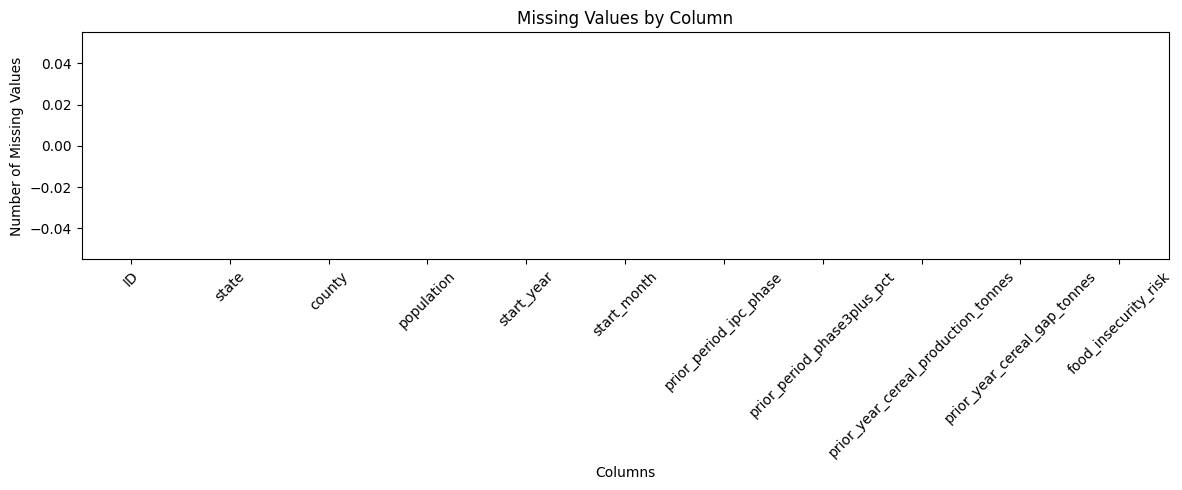

In [ ]:
plt.figure(figsize=(12, 5))

df.isnull().sum().plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Check duplicated rows**

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


remove duplicates:

In [ ]:
df = df.drop_duplicates()

print("New dataset shape:", df.shape)

New dataset shape: (3099, 11)


**Descriptive statistics**

In [ ]:
df.describe()

,population,start_year,start_month,prior_period_phase3plus_pct,prior_year_cereal_production_tonnes,prior_year_cereal_gap_tonnes,food_insecurity_risk
count,3099.000000,3099.000000,3099.000000,3099.000000,3099.000000,3099.000000,3099.000000
mean,151547.566312,2018.808325,5.867054,42.979606,11830.981068,-5129.659824,0.777348
std,99717.305952,3.077656,3.633253,24.200604,24916.525434,25051.808437,0.416094
min,7693.000000,2014.000000,1.000000,0.000000,0.000000,-70488.000000,0.000000
25%,77992.500000,2016.000000,2.000000,20.000000,1900.000000,-10989.500000,1.000000
50%,129349.000000,2018.000000,5.000000,45.300000,6421.000000,-5417.000000,1.000000
75%,191765.000000,2022.000000,9.000000,60.400000,16790.000000,-1656.000000,1.000000
max,807040.000000,2025.000000,12.000000,100.900000,614643.000000,625499.000000,1.000000


**Descriptive statistics for categorical variables**

In [ ]:
df.describe(include="object")

,ID,state,county,prior_period_ipc_phase
count,3099,3099,3099,3099
unique,3099,11,79,5
top,ID_826BHY,Upper Nile,Juba,Crisis
freq,1,472,40,1604


**Number of States**

In [ ]:
print("Number of states:", df["state"].nunique())

Number of states: 11


List of States

In [ ]:
df["state"].unique()

array(['Abyei', 'Central Equatoria', 'Eastern Equatoria', 'Jonglei',
       'Lakes', 'Northern Bahr El Ghazal', 'Unity', 'Upper Nile',
       'Warrap', 'Western Bahr El Ghazal', 'Western Equatoria'],
      dtype=object)

**Number of Counties**

In [ ]:

print("Number of counties:", df["county"].nunique())

Number of counties: 79


List of Counties

In [ ]:
df["county"].unique()

array(['Abyei', 'Juba', 'Kajo Keji', 'Lainya', 'Morobo', 'Terekeka',
       'Yei', 'Budi', 'Ikotos', 'Kapoeta East', 'Kapoeta North',
       'Kapoeta South', 'Lafon', 'Magwi', 'Torit', 'Akobo', 'Ayod',
       'Bor South', 'Canal/Pigi', 'Duk', 'Fangak', 'Nyirol', 'Pibor',
       'Pochalla', 'Twic East', 'Uror', 'Awerial', 'Cueibet',
       'Rumbek Centre', 'Rumbek East', 'Rumbek North', 'Wulu',
       'Yirol East', 'Yirol West', 'Aweil Centre', 'Aweil East',
       'Aweil North', 'Aweil South', 'Aweil West', 'Abiemnhom', 'Guit',
       'Koch', 'Leer', 'Mayendit', 'Mayom', 'Panyijiar', 'Pariang',
       'Rubkona', 'Baliet', 'Fashoda', 'Longochuk', 'Luakpiny/Nasir',
       'Maban', 'Maiwut', 'Malakal', 'Manyo', 'Melut', 'Panyikang',
       'Renk', 'Ulang', 'Gogrial East', 'Gogrial West', 'Tonj East',
       'Tonj North', 'Tonj South', 'Twic', 'Jur River', 'Raga', 'Wau',
       'Ezo', 'Ibba', 'Maridi', 'Mundri East', 'Mundri West', 'Mvolo',
       'Nagero', 'Nzara', 'Tambura', 'Yambio'], d

**Number of observations per state**

In [ ]:
state_counts = df["state"].value_counts()

state_counts

,count
state,
Upper Nile,472
Jonglei,438
Western Equatoria,400
Unity,360
Lakes,320
Eastern Equatoria,320
Warrap,240
Central Equatoria,226
Northern Bahr El Ghazal,200


Visualization:

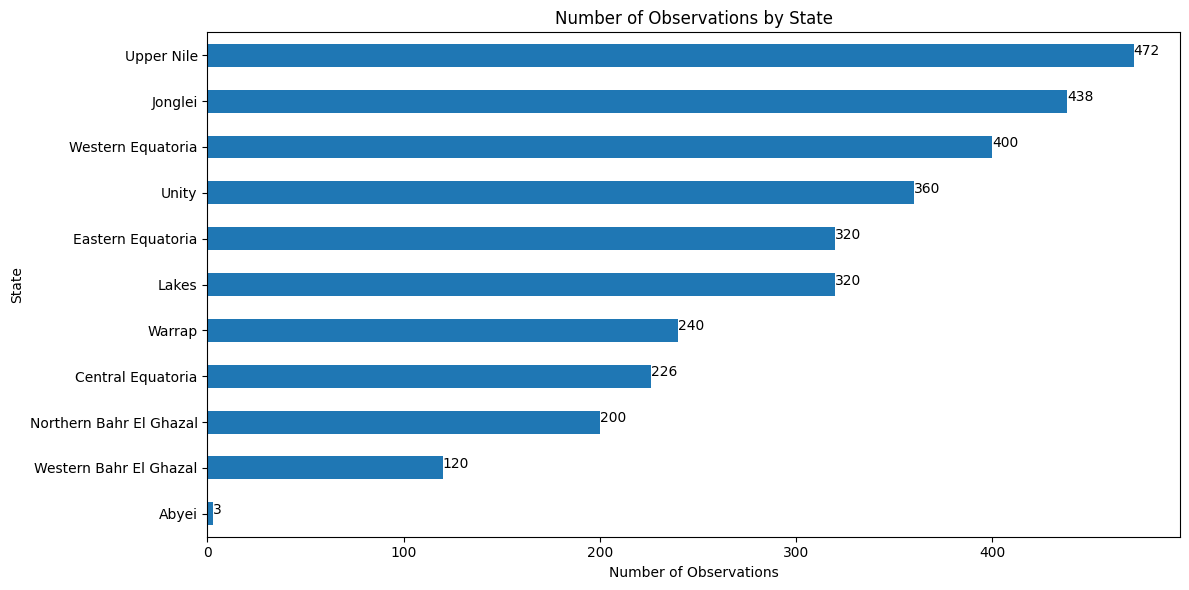

In [ ]:
plt.figure(figsize=(12, 6))

state_counts_sorted = state_counts.sort_values()
state_counts_sorted.plot(kind="barh")

for index, value in enumerate(state_counts_sorted):
    plt.text(value, index, str(value))

plt.title("Number of Observations by State")
plt.xlabel("Number of Observations")
plt.ylabel("State")
plt.tight_layout()
plt.show()

**Number of observations per county**

In [ ]:
county_counts = df["county"].value_counts()

county_counts.head(20)

,count
county,
Juba,40
Kajo Keji,40
Kapoeta South,40
Kapoeta North,40
Kapoeta East,40
Ikotos,40
Budi,40
Magwi,40
Lafon,40


Top 20 counties:

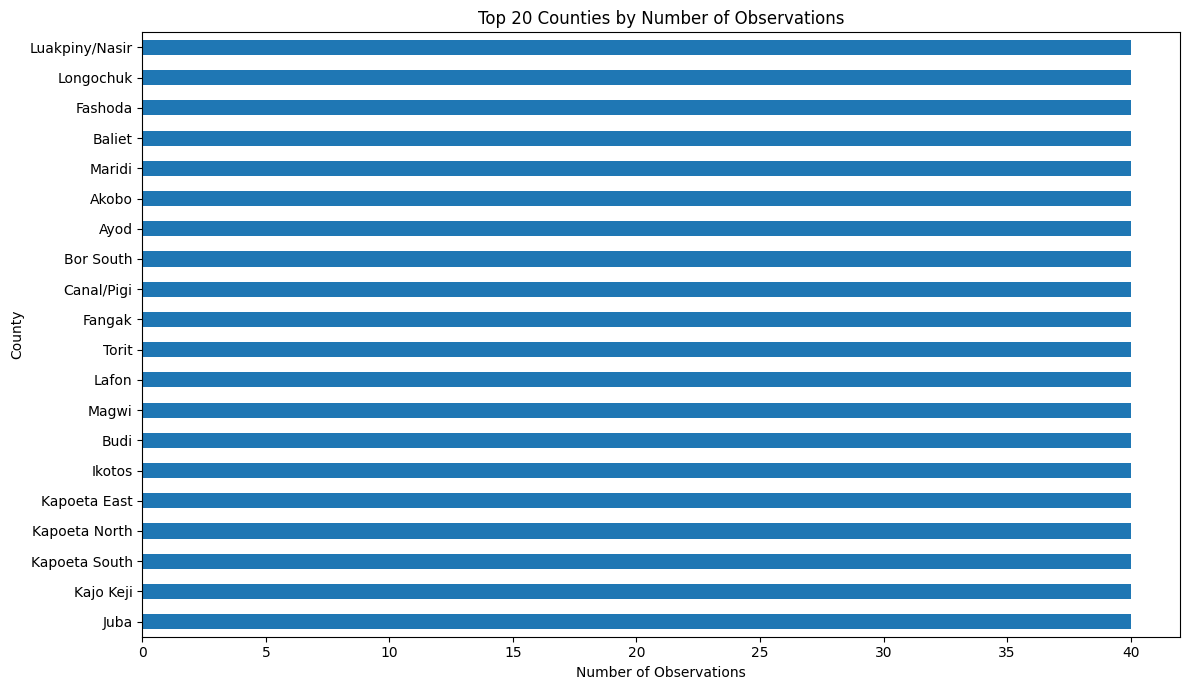

In [ ]:
plt.figure(figsize=(12, 7))

county_counts.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Counties by Number of Observations")
plt.xlabel("Number of Observations")
plt.ylabel("County")

plt.tight_layout()
plt.show()

**Analyze the target variable**

Check values:

In [ ]:
df["food_insecurity_risk"].value_counts()

,count
food_insecurity_risk,
1,2409
0,690


Percentage:

In [ ]:
target_percentage = (
    df["food_insecurity_risk"]
    .value_counts(normalize=True) * 100
)

target_percentage

,proportion
food_insecurity_risk,
1,77.734753
0,22.265247


**Target visualization**

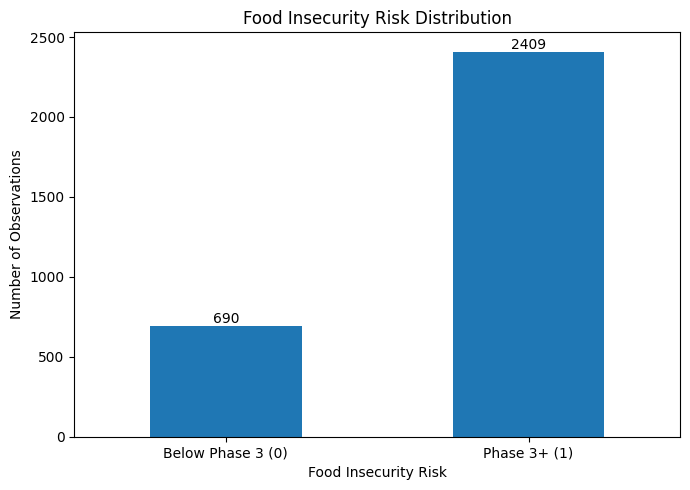

In [ ]:
plt.figure(figsize=(7, 5))

risk_counts = df["food_insecurity_risk"].value_counts().sort_index()
risk_counts.plot(kind="bar")

for index, value in enumerate(risk_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title("Food Insecurity Risk Distribution")
plt.xlabel("Food Insecurity Risk")
plt.ylabel("Number of Observations")

plt.xticks(
    [0, 1],
    ["Below Phase 3 (0)", "Phase 3+ (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

**Target pie chart**

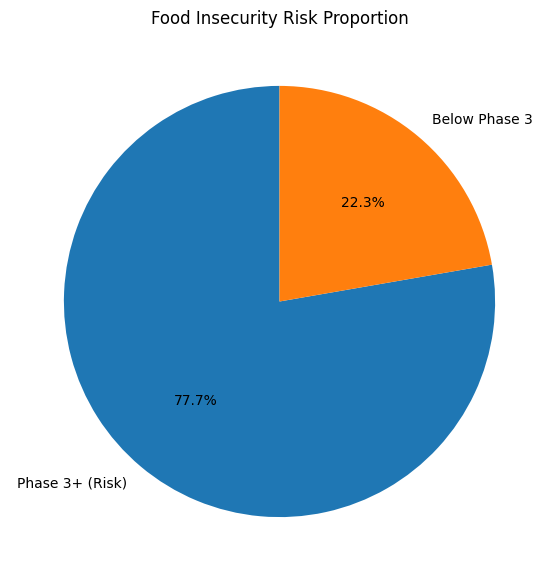

In [ ]:
target_counts = df["food_insecurity_risk"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    target_counts,
    labels=["Phase 3+ (Risk)", "Below Phase 3"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Food Insecurity Risk Proportion")

plt.show()

**Analyze previous IPC phase**

In [ ]:
ipc_counts = df["prior_period_ipc_phase"].value_counts()

ipc_counts

,count
prior_period_ipc_phase,
Crisis,1604
Emergency,756
Stressed,589
Minimal,144
Catastrophe,6


**Visualization:**

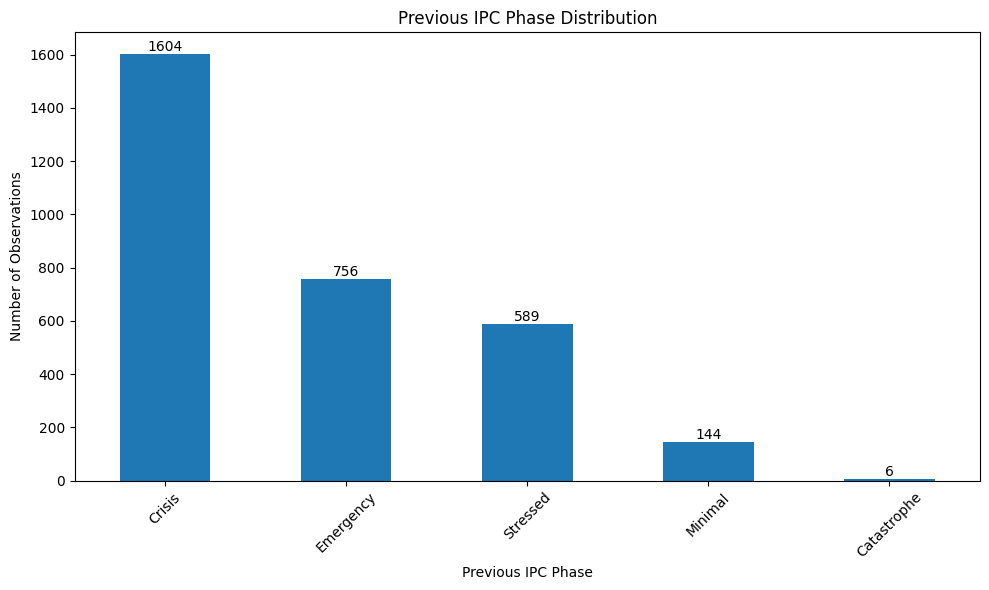

In [ ]:
plt.figure(figsize=(10, 6))

ipc_counts.plot(kind="bar")

for index, value in enumerate(ipc_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title("Previous IPC Phase Distribution")
plt.xlabel("Previous IPC Phase")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Previous IPC phase vs food insecurity risk**

In [ ]:
ipc_risk = pd.crosstab(
    df["prior_period_ipc_phase"],
    df["food_insecurity_risk"]
)

ipc_risk

food_insecurity_risk,0,1
prior_period_ipc_phase,,
Catastrophe,0,6
Crisis,180,1424
Emergency,5,751
Minimal,136,8
Stressed,369,220


Visualization:

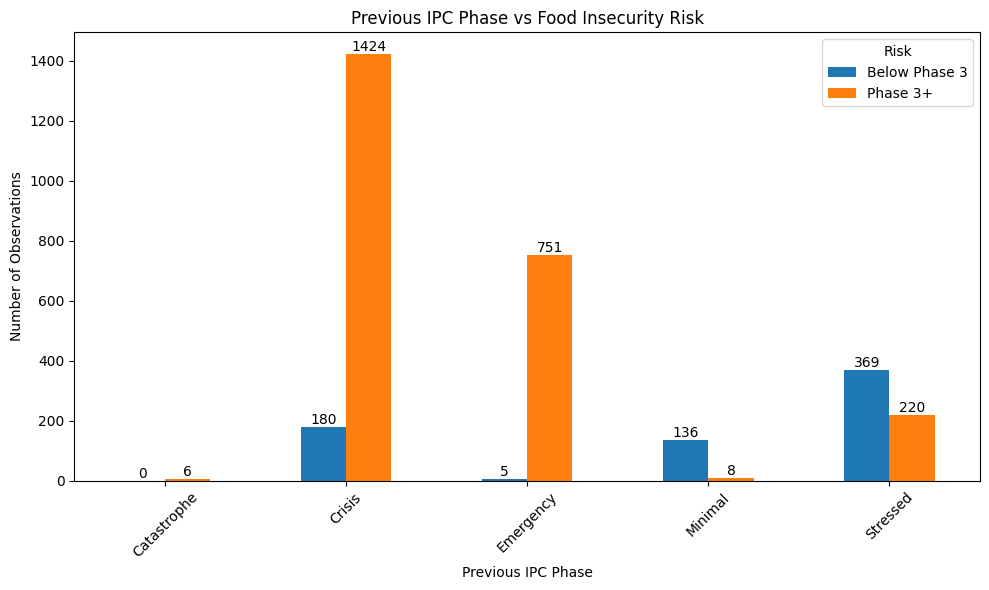

In [ ]:
ax = ipc_risk.plot(
    kind="bar",
    figsize=(10, 6)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Previous IPC Phase vs Food Insecurity Risk")
plt.xlabel("Previous IPC Phase")
plt.ylabel("Number of Observations")

plt.xticks(rotation=45)
plt.legend(
    ["Below Phase 3", "Phase 3+"],
    title="Risk"
)

plt.tight_layout()
plt.show()

**Average food insecurity risk per state**

In [ ]:
state_risk_avg = df.groupby('state')['food_insecurity_risk'].mean().sort_values(ascending=False)
display(state_risk_avg)

,food_insecurity_risk
state,
Abyei,1.000000
Unity,0.950000
Northern Bahr El Ghazal,0.905000
Upper Nile,0.879237
Jonglei,0.865297
Warrap,0.800000
Lakes,0.790625
Eastern Equatoria,0.771875
Western Bahr El Ghazal,0.766667


**Visualization: Average food insecurity risk per state**

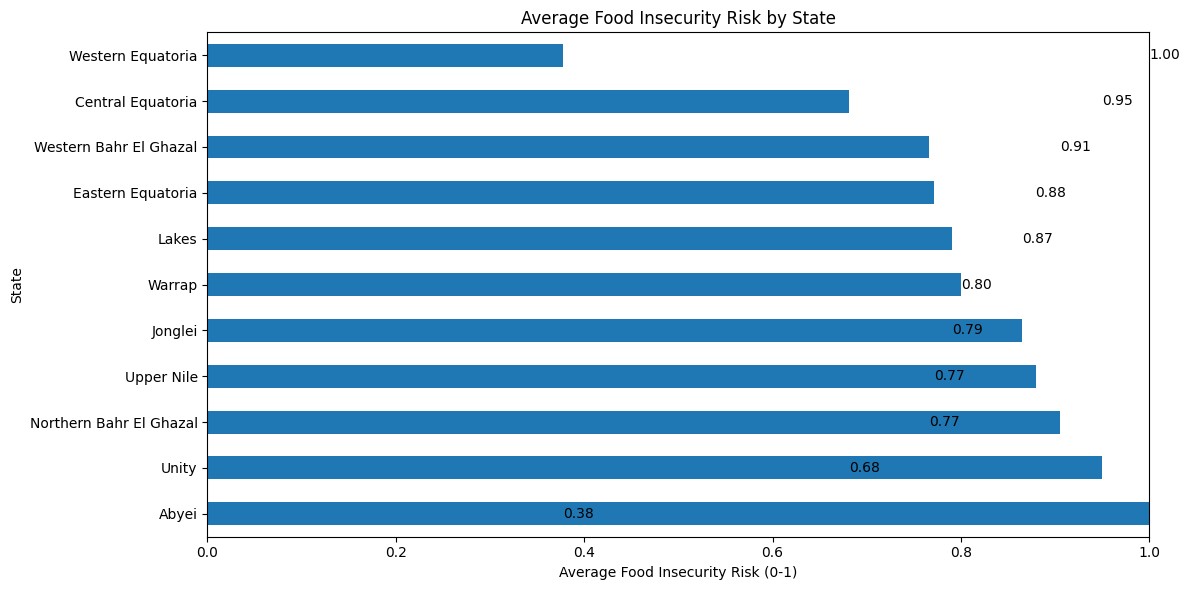

In [ ]:
plt.figure(figsize=(12, 6))
state_risk_avg.plot(kind='barh')

for index, value in enumerate(state_risk_avg.sort_values()):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.title('Average Food Insecurity Risk by State')
plt.xlabel('Average Food Insecurity Risk (0-1)')
plt.ylabel('State')
plt.xlim(0, 1) # Risk is between 0 and 1
plt.tight_layout()
plt.show()

**Calculate risk percentage by previous IPC phase**

In [ ]:
ipc_risk_percentage = pd.crosstab(
    df["prior_period_ipc_phase"],
    df["food_insecurity_risk"],
    normalize="index"
) * 100

ipc_risk_percentage

food_insecurity_risk,0,1
prior_period_ipc_phase,,
Catastrophe,0.000000,100.000000
Crisis,11.221945,88.778055
Emergency,0.661376,99.338624
Minimal,94.444444,5.555556
Stressed,62.648557,37.351443


Plot:

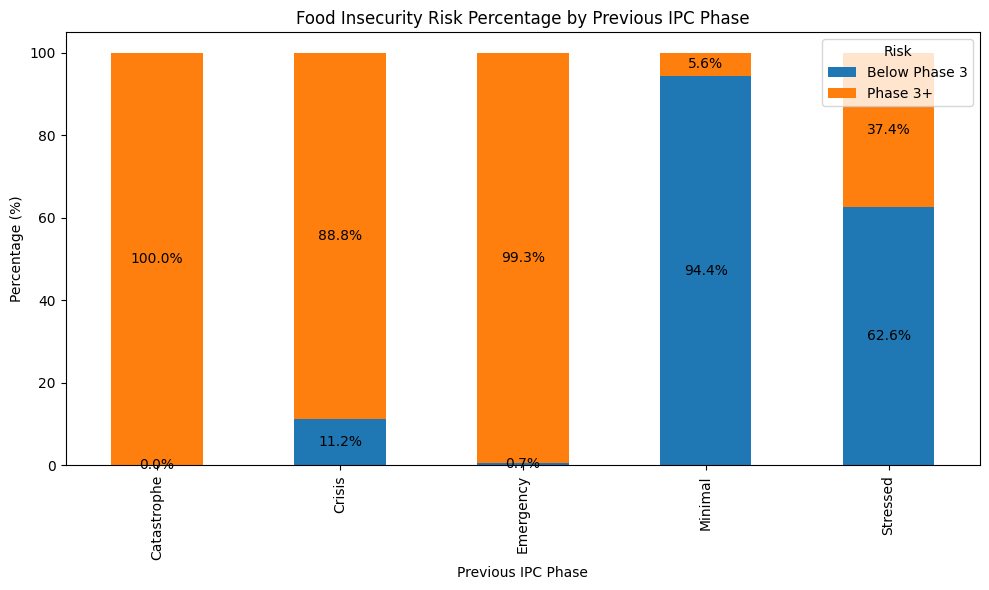

In [ ]:
ax = ipc_risk_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.title(
    "Food Insecurity Risk Percentage by Previous IPC Phase"
)

plt.xlabel("Previous IPC Phase")
plt.ylabel("Percentage (%)")

plt.legend(
    ["Below Phase 3", "Phase 3+"],
    title="Risk"
)

plt.tight_layout()
plt.show()

**Analyze Phase 3+ percentage**

In [ ]:
df["prior_period_phase3plus_pct"].describe()

,prior_period_phase3plus_pct
count,3099.000000
mean,42.979606
std,24.200604
min,0.000000
25%,20.000000
50%,45.300000
75%,60.400000
max,100.900000


Histogram:

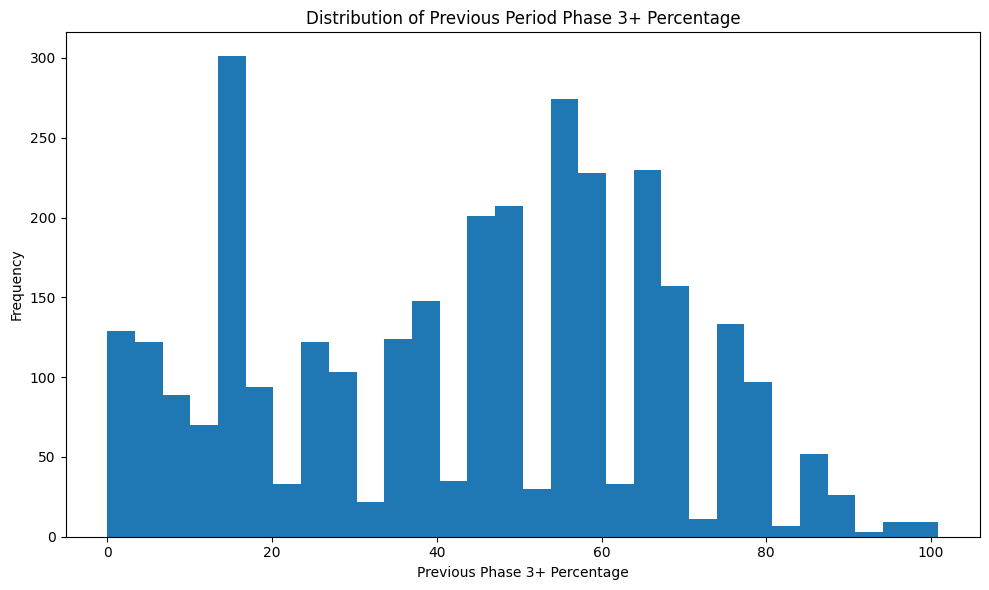

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["prior_period_phase3plus_pct"],
    bins=30
)

plt.title("Distribution of Previous Period Phase 3+ Percentage")
plt.xlabel("Previous Phase 3+ Percentage")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Phase 3+ percentage vs risk**

<Figure size 800x600 with 0 Axes>

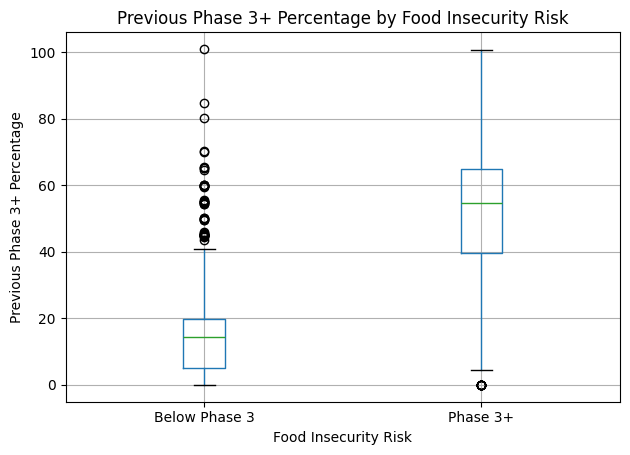

In [ ]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column="prior_period_phase3plus_pct",
    by="food_insecurity_risk"
)

plt.title("Previous Phase 3+ Percentage by Food Insecurity Risk")
plt.suptitle("")
plt.xlabel("Food Insecurity Risk")
plt.ylabel("Previous Phase 3+ Percentage")

plt.xticks(
    [1, 2],
    ["Below Phase 3", "Phase 3+"]
)

plt.tight_layout()
plt.show()

**Population analysis**

In [ ]:
df["population"].describe()

,population
count,3099.000000
mean,151547.566312
std,99717.305952
min,7693.000000
25%,77992.500000
50%,129349.000000
75%,191765.000000
max,807040.000000


Histogram:

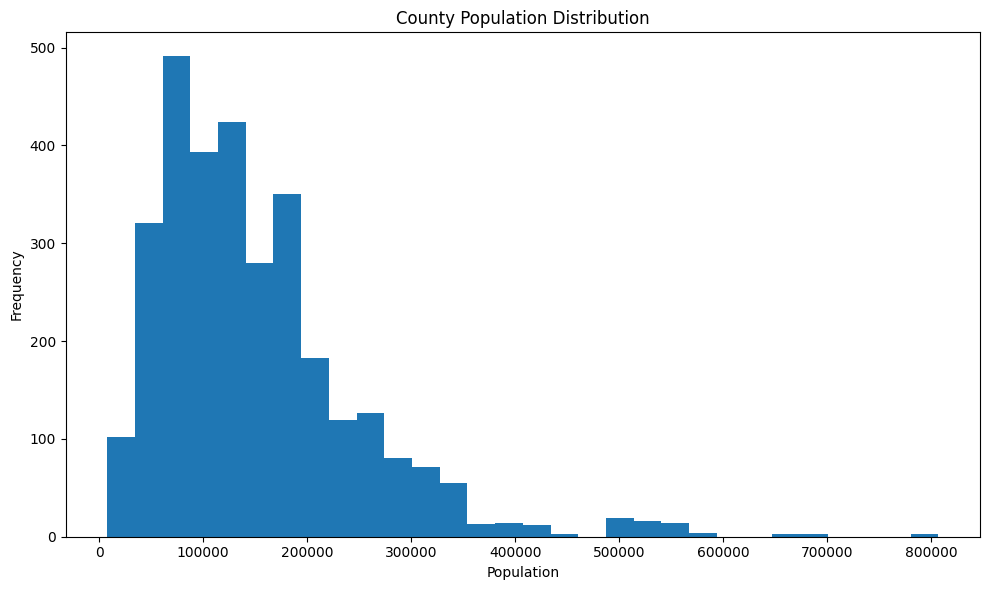

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["population"],
    bins=30
)

plt.title("County Population Distribution")
plt.xlabel("Population")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Population vs food insecurity risk**

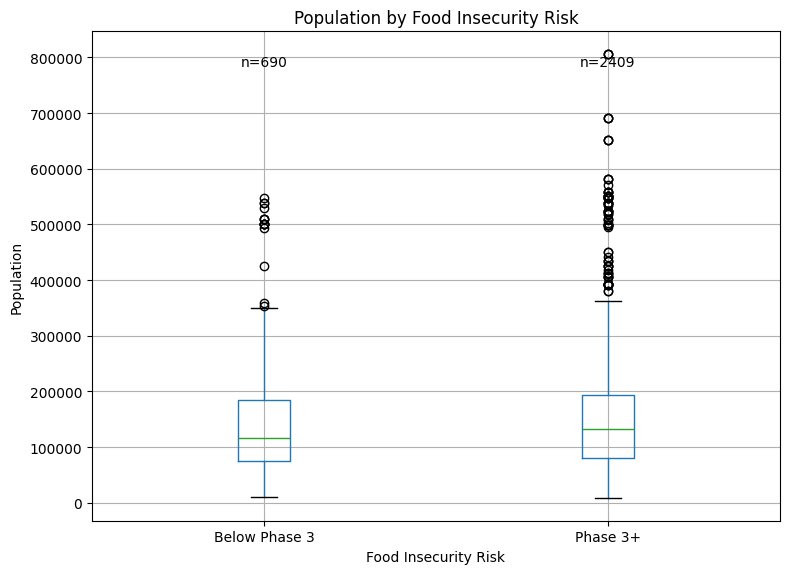

In [ ]:
plt.figure(figsize=(8, 6))

ax = df.boxplot(
    column="population",
    by="food_insecurity_risk",
    ax=plt.gca()
)

risk_counts = df["food_insecurity_risk"].value_counts().sort_index()

for i, count in enumerate(risk_counts):
    x_coord = i + 1  # Boxplot categories are typically 1-indexed
    # Place the text slightly above the median line or top of the box
    # For a general placement, we can use a fixed height or dynamically find it
    # A fixed placement slightly above the top of the plot area might be clearer for counts
    plt.text(x_coord, ax.get_ylim()[1] * 0.95, f'n={count}', ha='center', va='top', color='black', fontsize=10)

plt.title("Population by Food Insecurity Risk")
plt.suptitle("") # Suppress the default suptitle generated by `by` parameter

plt.xlabel("Food Insecurity Risk")
plt.ylabel("Population")

plt.xticks(
    [1, 2],
    ["Below Phase 3", "Phase 3+"]
)

plt.tight_layout()
plt.show()

**Cereal production analysis**

In [ ]:
df["prior_year_cereal_production_tonnes"].describe()

,prior_year_cereal_production_tonnes
count,3099.000000
mean,11830.981068
std,24916.525434
min,0.000000
25%,1900.000000
50%,6421.000000
75%,16790.000000
max,614643.000000


Histogram:

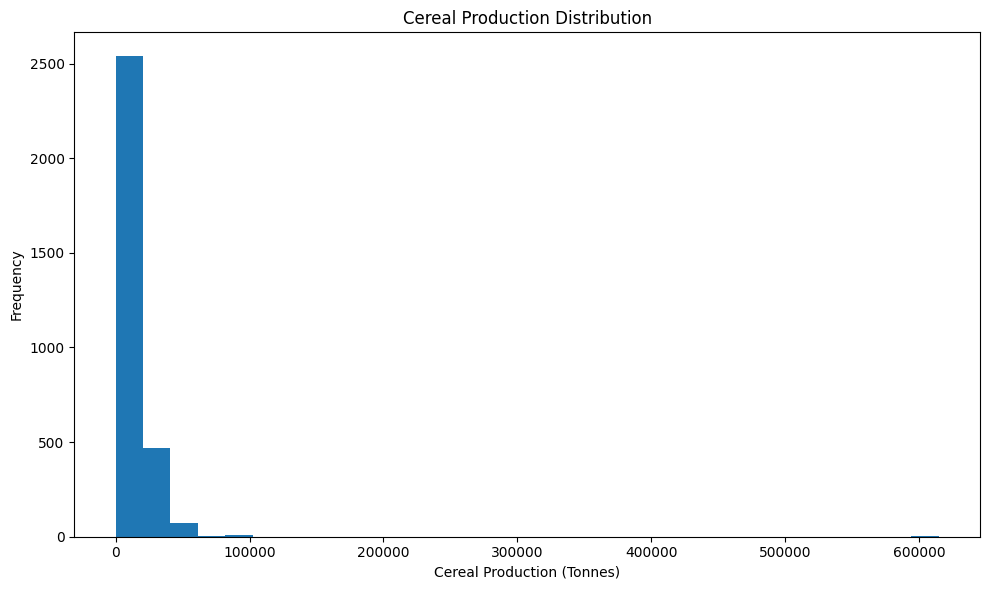

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["prior_year_cereal_production_tonnes"],
    bins=30
)

plt.title("Cereal Production Distribution")
plt.xlabel("Cereal Production (Tonnes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Cereal production vs risk**

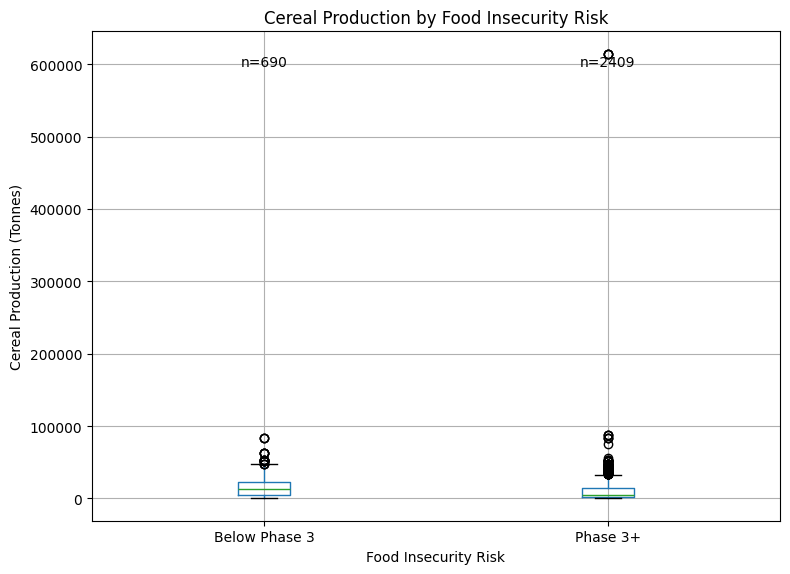

In [ ]:
plt.figure(figsize=(8, 6))

ax = df.boxplot(
    column="prior_year_cereal_production_tonnes",
    by="food_insecurity_risk",
    ax=plt.gca()
)

risk_counts = df["food_insecurity_risk"].value_counts().sort_index()

for i, count in enumerate(risk_counts):
    x_coord = i + 1  # Boxplot categories are typically 1-indexed
    plt.text(x_coord, ax.get_ylim()[1] * 0.95, f'n={count}', ha='center', va='top', color='black', fontsize=10)

plt.title("Cereal Production by Food Insecurity Risk")
plt.suptitle("") # Suppress the default suptitle generated by `by` parameter

plt.xlabel("Food Insecurity Risk")
plt.ylabel("Cereal Production (Tonnes)")

plt.xticks(
    [1, 2],
    ["Below Phase 3", "Phase 3+"]
)

plt.tight_layout()
plt.show()

**Cereal gap analysis**

In [ ]:
df["prior_year_cereal_gap_tonnes"].describe()

,prior_year_cereal_gap_tonnes
count,3099.000000
mean,-5129.659824
std,25051.808437
min,-70488.000000
25%,-10989.500000
50%,-5417.000000
75%,-1656.000000
max,625499.000000


Histogram:

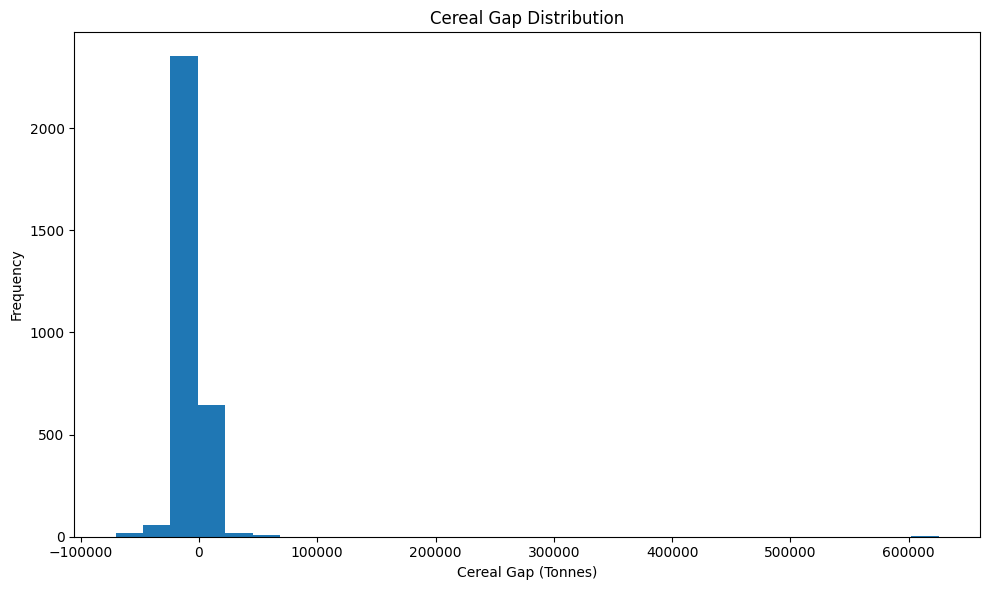

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["prior_year_cereal_gap_tonnes"],
    bins=30
)

plt.title("Cereal Gap Distribution")
plt.xlabel("Cereal Gap (Tonnes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Cereal gap vs risk**

<Figure size 800x600 with 0 Axes>

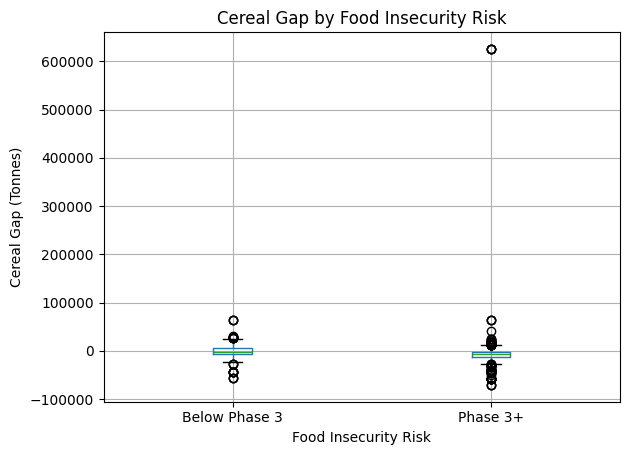

In [ ]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column="prior_year_cereal_gap_tonnes",
    by="food_insecurity_risk"
)

plt.title("Cereal Gap by Food Insecurity Risk")
plt.suptitle("")

plt.xlabel("Food Insecurity Risk")
plt.ylabel("Cereal Gap (Tonnes)")

plt.xticks(
    [1, 2],
    ["Below Phase 3", "Phase 3+"]
)

plt.tight_layout()
plt.show()

**Analyze years**

In [ ]:
year_counts = df["start_year"].value_counts().sort_index()

year_counts

,count
start_year,
2014,78
2015,388
2016,390
2017,464
2018,380
2019,229
2020,312
2022,310
2023,234


Visualization:

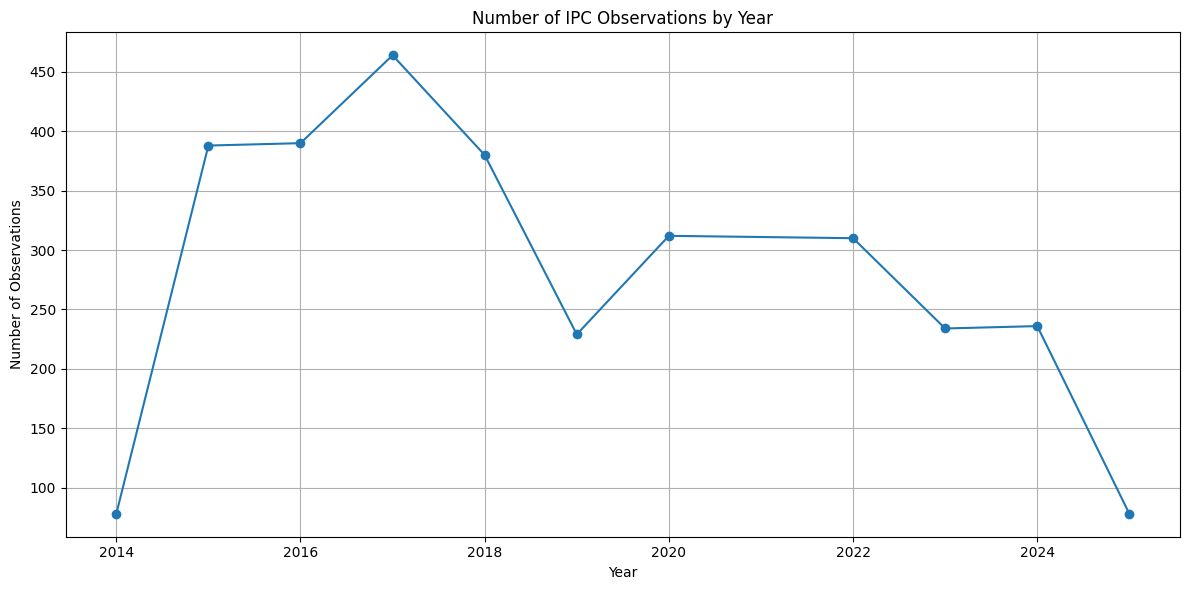

In [ ]:
plt.figure(figsize=(12, 6))

year_counts.plot(kind="line", marker="o")

plt.title("Number of IPC Observations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.grid(True)

plt.tight_layout()
plt.show()

**Food insecurity risk over time**

In [ ]:
year_risk = df.groupby(
    "start_year"
)["food_insecurity_risk"].mean() * 100

year_risk

,food_insecurity_risk
start_year,
2014,21.794872
2015,53.608247
2016,56.410256
2017,77.801724
2018,86.842105
2019,85.152838
2020,87.500000
2022,95.806452
2023,92.735043


Plot:

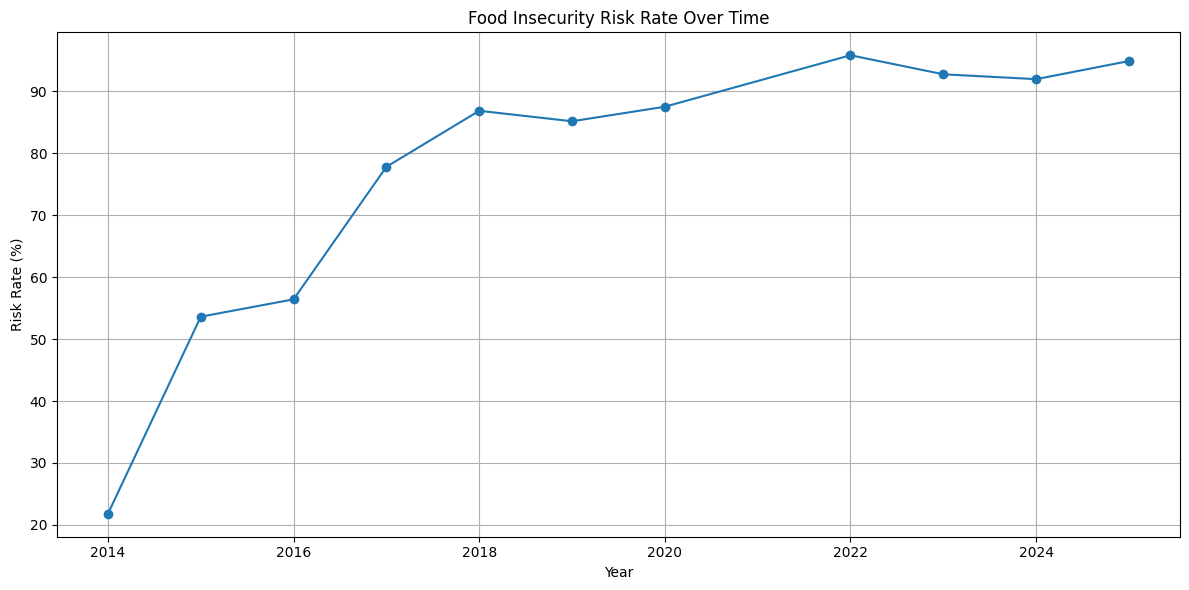

In [ ]:
plt.figure(figsize=(12, 6))

year_risk.plot(
    kind="line",
    marker="o"
)

plt.title("Food Insecurity Risk Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Risk Rate (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

**Create a proper date column**

In [ ]:
df["period_date"] = pd.to_datetime(
    df["start_year"].astype(str)
    + "-"
    + df["start_month"].astype(str)
    + "-01"
)

df.head()

,ID,state,county,population,start_year,start_month,prior_period_ipc_phase,prior_period_phase3plus_pct,prior_year_cereal_production_tonnes,prior_year_cereal_gap_tonnes,food_insecurity_risk,period_date
0,ID_XAJI0Y,Abyei,Abyei,69160,2023,12,Crisis,49.2,12642.31115,-4404.321583,1,2023-12-01
1,ID_6DPBHS,Abyei,Abyei,70246,2024,4,Crisis,30.4,12642.31115,-4404.321583,1,2024-04-01
2,ID_AHXTHV,Abyei,Abyei,70246,2024,9,Crisis,55.5,12642.31115,-4404.321583,1,2024-09-01
3,ID_3A3ZMF,Central Equatoria,Juba,492966,2014,10,Stressed,15.0,19333.52632,-44684.973680,0,2014-10-01
4,ID_8MDD4V,Central Equatoria,Juba,501659,2015,1,Stressed,10.1,19333.52632,-44684.973680,0,2015-01-01


**Sort chronologically**

In [ ]:
df = df.sort_values(
    by="period_date"
).reset_index(drop=True)

df[
    [
        "state",
        "county",
        "period_date",
        "food_insecurity_risk"
    ]
].head(20)

,state,county,period_date,food_insecurity_risk
0,Central Equatoria,Lainya,2014-10-01,0
1,Northern Bahr El Ghazal,Aweil East,2014-10-01,0
2,Central Equatoria,Yei,2014-10-01,0
3,Jonglei,Bor South,2014-10-01,0
4,Eastern Equatoria,Kapoeta East,2014-10-01,0
5,Northern Bahr El Ghazal,Aweil Centre,2014-10-01,0
6,Western Equatoria,Ibba,2014-10-01,0
7,Western Bahr El Ghazal,Jur River,2014-10-01,0
8,Western Equatoria,Mundri West,2014-10-01,0
9,Unity,Mayendit,2014-10-01,1


**Monthly food insecurity trend**

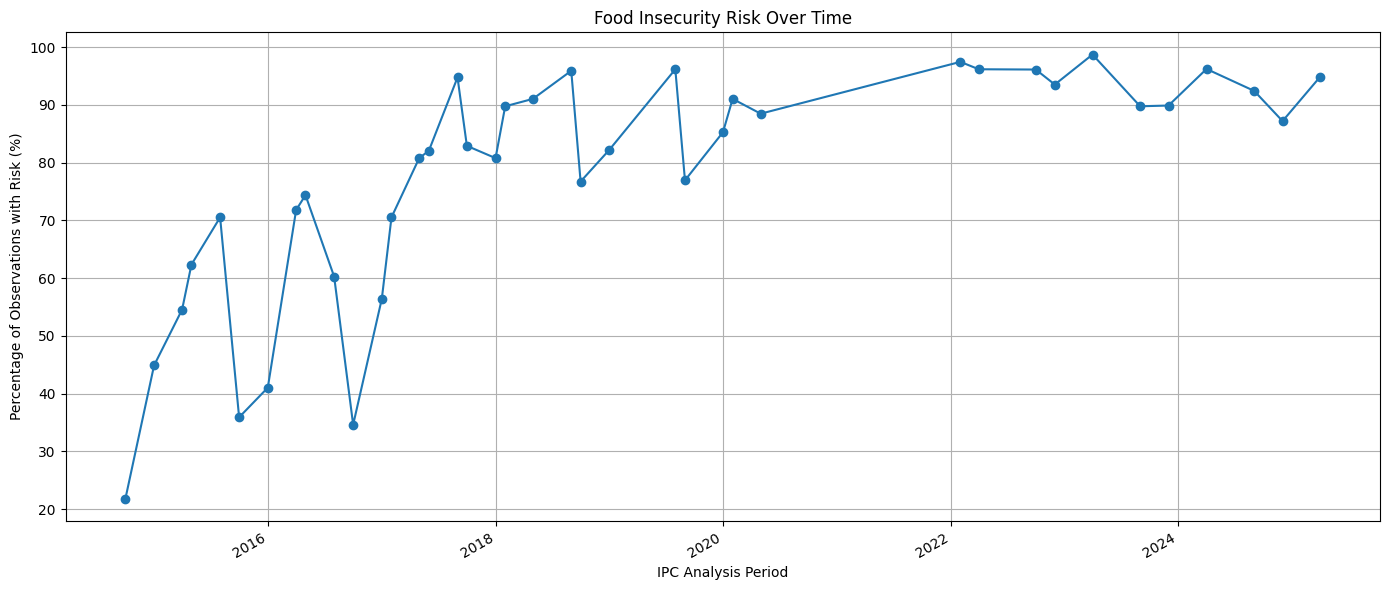

In [ ]:
monthly_risk = (
    df.groupby("period_date")["food_insecurity_risk"]
    .mean()
    * 100
)

plt.figure(figsize=(14, 6))

monthly_risk.plot(
    kind="line",
    marker="o"
)

plt.title("Food Insecurity Risk Over Time")
plt.xlabel("IPC Analysis Period")
plt.ylabel("Percentage of Observations with Risk (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

**Risk by state**

In [ ]:
state_risk = (
    df.groupby("state")["food_insecurity_risk"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

state_risk

,food_insecurity_risk
state,
Abyei,100.000000
Unity,95.000000
Northern Bahr El Ghazal,90.500000
Upper Nile,87.923729
Jonglei,86.529680
Warrap,80.000000
Lakes,79.062500
Eastern Equatoria,77.187500
Western Bahr El Ghazal,76.666667


Visualization:

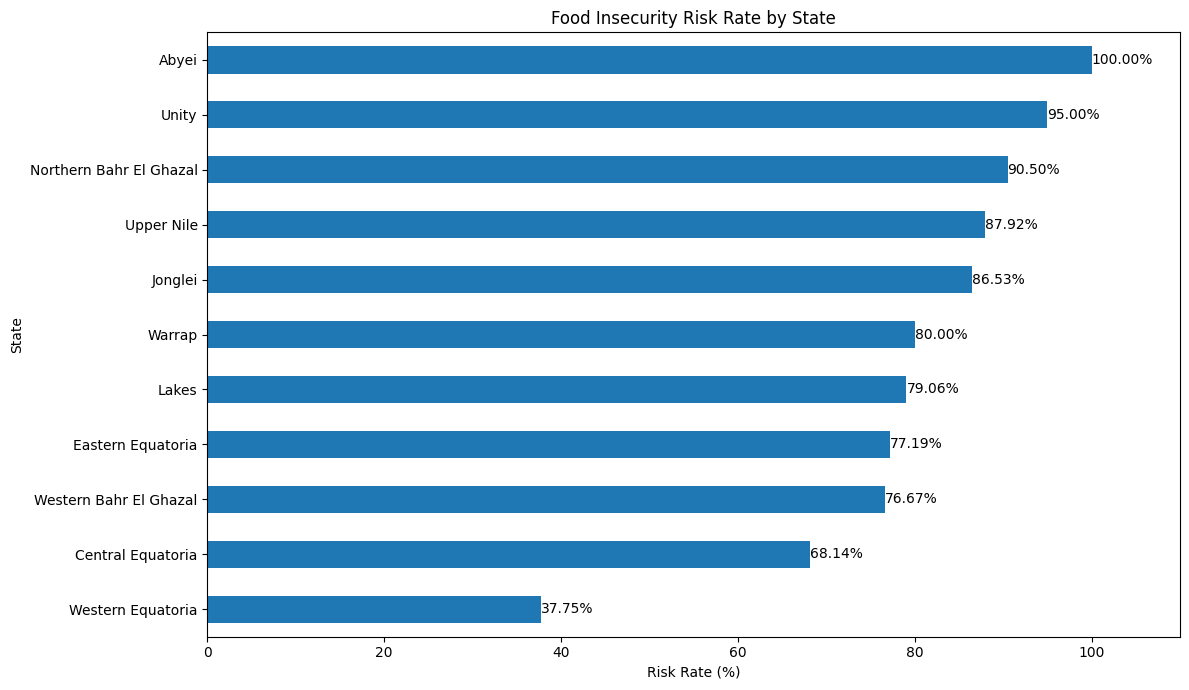

In [ ]:
plt.figure(figsize=(12, 7))

ax = state_risk.sort_values().plot(
    kind="barh"
)

for index, value in enumerate(state_risk.sort_values()):
    plt.text(value, index, f'{value:.2f}%', va='center') # Add percentage sign and format to 2 decimal places

plt.title("Food Insecurity Risk Rate by State")
plt.xlabel("Risk Rate (%)")
plt.ylabel("State")

# Adjust x-axis limit slightly to make space for labels if needed
plt.xlim(0, max(state_risk.max() * 1.1, 100)) # Ensure max is at least 100 for percentage and add some buffer

plt.tight_layout()
plt.show()

**Risk by county**

In [ ]:
county_risk = (
    df.groupby("county")["food_insecurity_risk"]
    .agg(["mean", "count"])
)

county_risk["risk_percentage"] = (
    county_risk["mean"] * 100
)

county_risk.sort_values(
    "risk_percentage",
    ascending=False
).head(20)

,mean,count,risk_percentage
county,,,
Abyei,1.000000,3,100.000000
Baliet,1.000000,40,100.000000
Mayom,1.000000,40,100.000000
Leer,1.000000,40,100.000000
Mayendit,1.000000,40,100.000000
Koch,1.000000,40,100.000000
Guit,1.000000,40,100.000000
Panyijiar,1.000000,40,100.000000
Fashoda,0.975000,40,97.500000


**Top counties by observed risk**

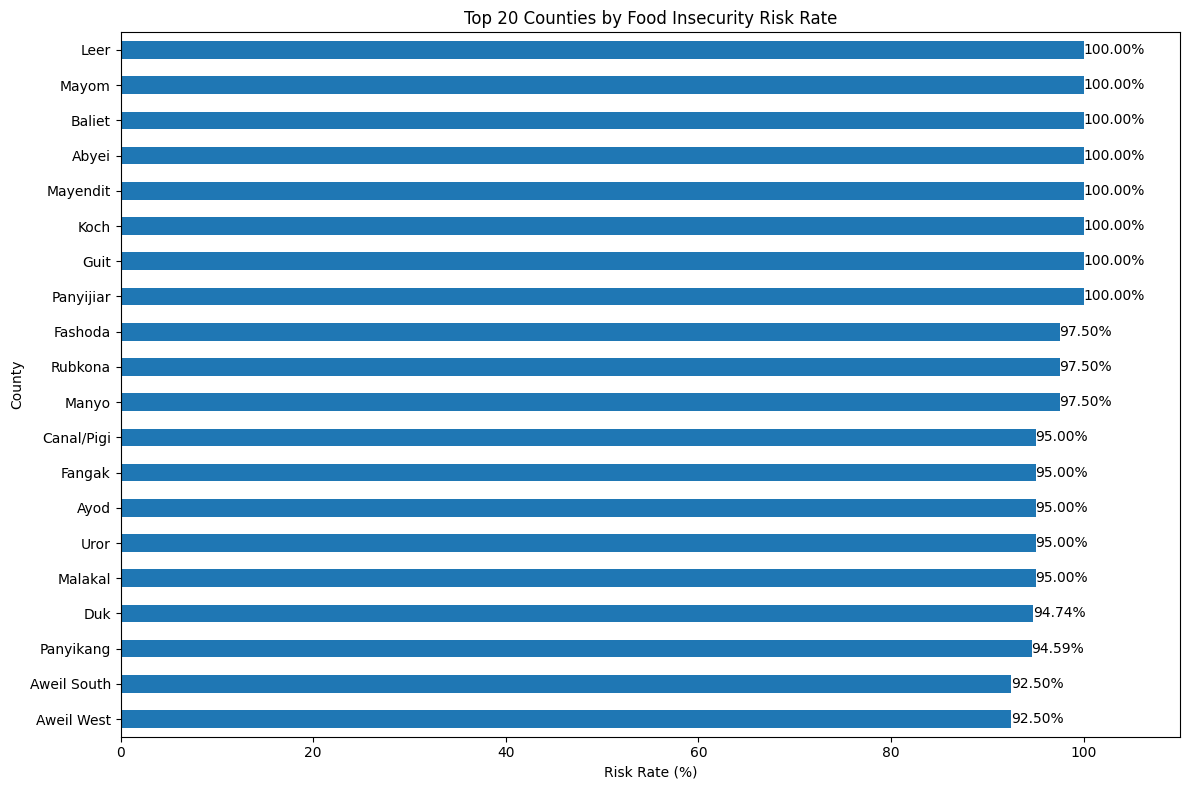

In [ ]:
top_counties = county_risk.sort_values(
    "risk_percentage",
    ascending=False
).head(20)

plt.figure(figsize=(12, 8))

ax = top_counties["risk_percentage"].sort_values().plot(
    kind="barh"
)

for index, value in enumerate(top_counties["risk_percentage"].sort_values()):
    plt.text(value, index, f'{value:.2f}%', va='center') # Add percentage sign and format to 2 decimal places

plt.title("Top 20 Counties by Food Insecurity Risk Rate")
plt.xlabel("Risk Rate (%)")
plt.ylabel("County")

plt.xlim(0, max(top_counties["risk_percentage"].max() * 1.1, 100)) # Adjust x-axis limit to accommodate labels
plt.tight_layout()
plt.show()

**Correlation analysis**

In [ ]:
numeric_columns = [
    "population",
    "start_year",
    "start_month",
    "prior_period_phase3plus_pct",
    "prior_year_cereal_production_tonnes",
    "prior_year_cereal_gap_tonnes",
    "food_insecurity_risk"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,population,start_year,start_month,prior_period_phase3plus_pct,prior_year_cereal_production_tonnes,prior_year_cereal_gap_tonnes,food_insecurity_risk
population,1.000000,0.011797,0.002431,0.007081,0.286176,-0.114793,0.061774
start_year,0.011797,1.000000,0.114228,0.325847,0.041626,0.029646,0.351310
start_month,0.002431,0.114228,1.000000,0.197443,0.018140,0.012413,0.001125
prior_period_phase3plus_pct,0.007081,0.325847,0.197443,1.000000,-0.161714,-0.132232,0.608444
prior_year_cereal_production_tonnes,0.286176,0.041626,0.018140,-0.161714,1.000000,0.881098,-0.085002
prior_year_cereal_gap_tonnes,-0.114793,0.029646,0.012413,-0.132232,0.881098,1.000000,-0.089523
food_insecurity_risk,0.061774,0.351310,0.001125,0.608444,-0.085002,-0.089523,1.000000


Visualize correlations

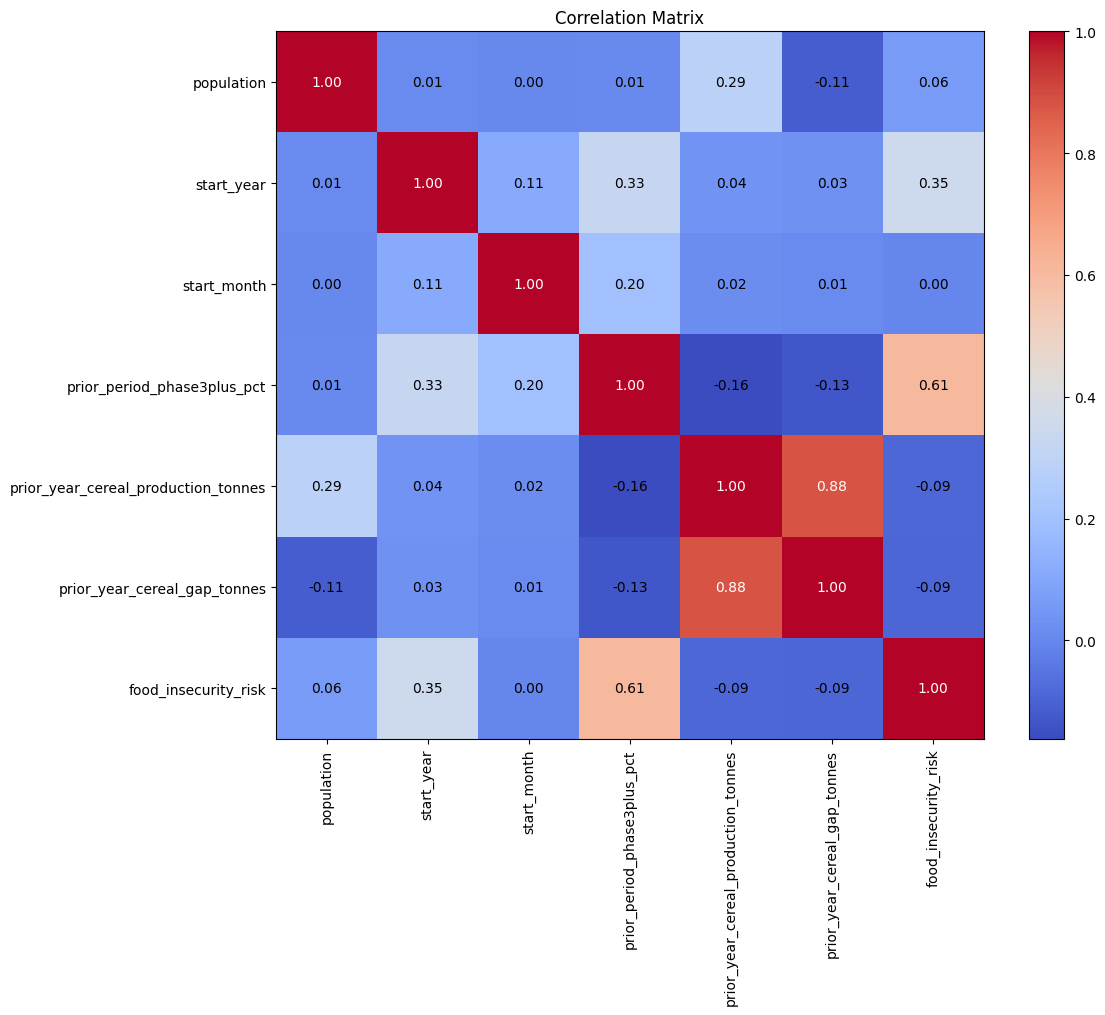

In [ ]:
plt.figure(figsize=(12, 10))

ax = plt.imshow(
    correlation_matrix,
    interpolation="nearest",
    cmap='coolwarm' # Using a divergent colormap for correlations
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add data labels to the heatmap
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text_color = 'black' if abs(correlation_matrix.iloc[i, j]) < 0.7 else 'white' # Set text color based on background for readability
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                 ha='center', va='center', color=text_color, fontsize=10)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

**Cereal production vs cereal gap**

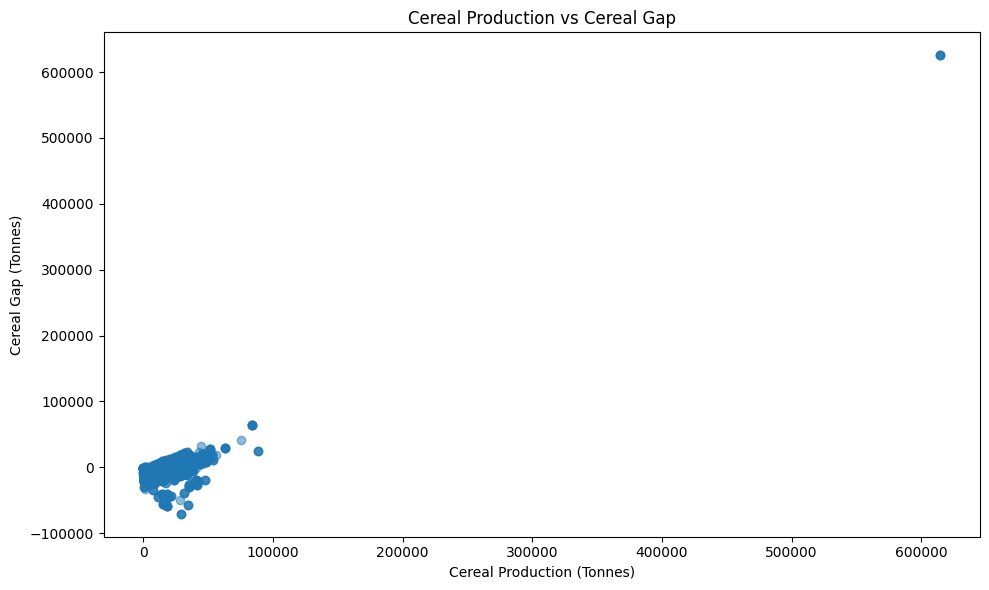

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["prior_year_cereal_production_tonnes"],
    df["prior_year_cereal_gap_tonnes"],
    alpha=0.5
)

plt.title("Cereal Production vs Cereal Gap")
plt.xlabel("Cereal Production (Tonnes)")
plt.ylabel("Cereal Gap (Tonnes)")

plt.tight_layout()
plt.show()

**Phase 3+ percentage vs cereal gap**

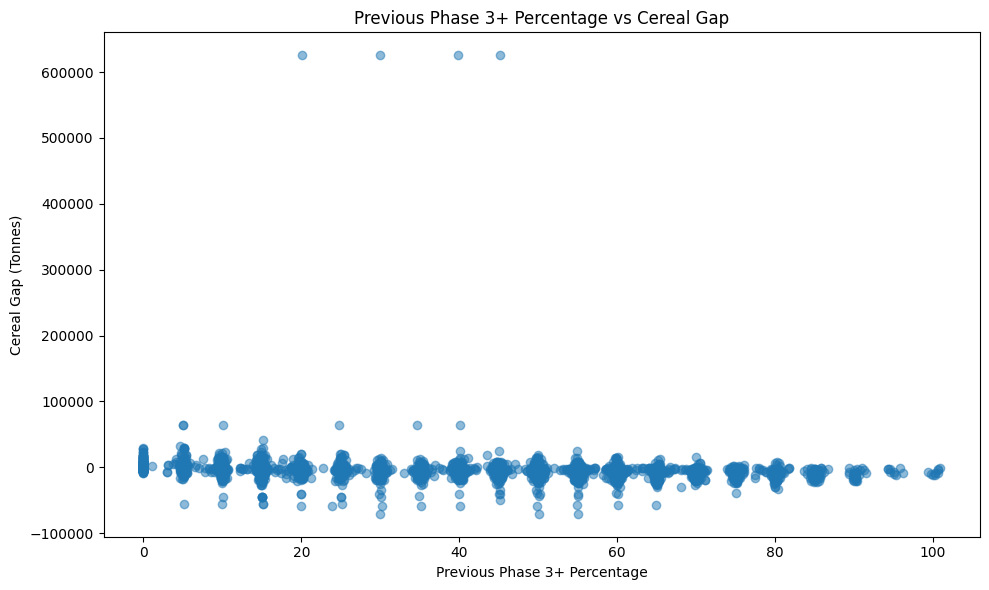

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["prior_period_phase3plus_pct"],
    df["prior_year_cereal_gap_tonnes"],
    alpha=0.5
)

plt.title(
    "Previous Phase 3+ Percentage vs Cereal Gap"
)

plt.xlabel("Previous Phase 3+ Percentage")
plt.ylabel("Cereal Gap (Tonnes)")

plt.tight_layout()
plt.show()

**Phase 3+ percentage vs population**

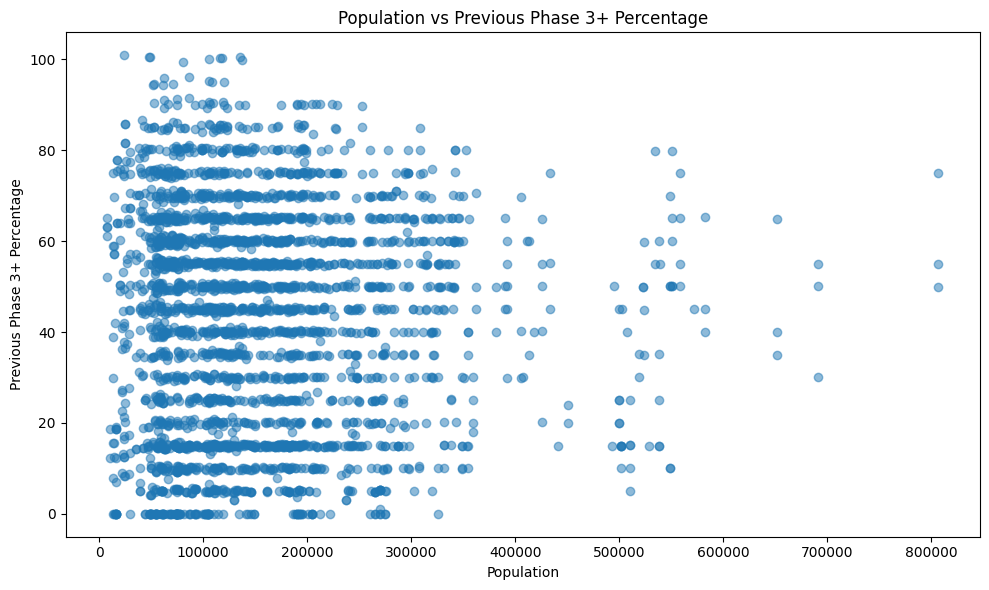

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["population"],
    df["prior_period_phase3plus_pct"],
    alpha=0.5
)

plt.title(
    "Population vs Previous Phase 3+ Percentage"
)

plt.xlabel("Population")
plt.ylabel("Previous Phase 3+ Percentage")

plt.tight_layout()
plt.show()

**Risk by month**

In [ ]:
month_risk = (
    df.groupby("start_month")["food_insecurity_risk"]
    .mean()
    * 100
)

month_risk

,food_insecurity_risk
start_month,
1,67.837338
2,87.179487
4,85.438972
5,79.434447
6,82.051282
8,75.641026
9,89.843750
10,57.608696
12,90.170940


Plot:

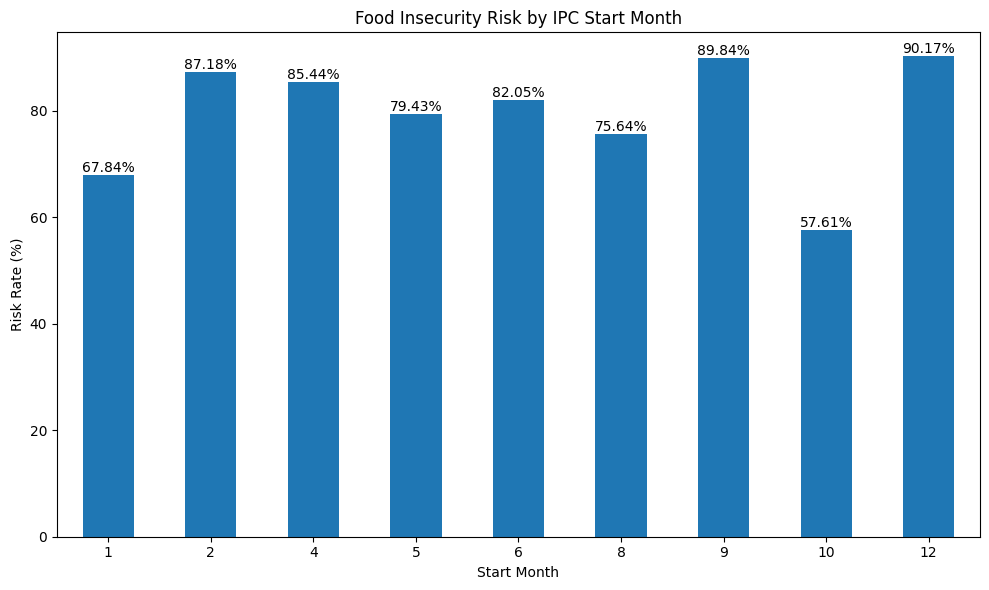

In [ ]:
plt.figure(figsize=(10, 6))

ax = month_risk.plot(
    kind="bar"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%') # Format as percentage with 2 decimal places

plt.title("Food Insecurity Risk by IPC Start Month")
plt.xlabel("Start Month")
plt.ylabel("Risk Rate (%)")

plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.tight_layout()
plt.show()

**State × risk cross-tabulation**

In [ ]:
state_target = pd.crosstab(
    df["state"],
    df["food_insecurity_risk"]
)

state_target

food_insecurity_risk,0,1
state,,
Abyei,0,3
Central Equatoria,72,154
Eastern Equatoria,73,247
Jonglei,59,379
Lakes,67,253
Northern Bahr El Ghazal,19,181
Unity,18,342
Upper Nile,57,415
Warrap,48,192


Percentage:

In [ ]:
state_target_percentage = pd.crosstab(
    df["state"],
    df["food_insecurity_risk"],
    normalize="index"
) * 100

state_target_percentage

food_insecurity_risk,0,1
state,,
Abyei,0.000000,100.000000
Central Equatoria,31.858407,68.141593
Eastern Equatoria,22.812500,77.187500
Jonglei,13.470320,86.529680
Lakes,20.937500,79.062500
Northern Bahr El Ghazal,9.500000,90.500000
Unity,5.000000,95.000000
Upper Nile,12.076271,87.923729
Warrap,20.000000,80.000000


**County × IPC phase**

In [ ]:
county_ipc = pd.crosstab(
    df["county"],
    df["prior_period_ipc_phase"]
)

county_ipc.head(20)

prior_period_ipc_phase,Catastrophe,Crisis,Emergency,Minimal,Stressed
county,,,,,
Abiemnhom,0,30,1,0,9
Abyei,0,3,0,0,0
Akobo,0,20,13,0,7
Aweil Centre,0,28,5,0,7
Aweil East,0,14,21,0,5
Aweil North,0,19,17,0,4
Aweil South,0,20,16,0,4
Aweil West,0,21,15,0,4
Awerial,0,22,9,0,9


**Population by state**

In [ ]:
population_by_state = (
    df.groupby("state")["population"]
    .mean()
    .sort_values(ascending=False)
)

population_by_state

,population
state,
Northern Bahr El Ghazal,255308.710000
Central Equatoria,242106.544248
Warrap,233350.600000
Western Bahr El Ghazal,190046.683333
Jonglei,162375.465753
Lakes,143567.353125
Eastern Equatoria,135290.287500
Unity,116874.877778
Upper Nile,105964.110169


**Visualization:**

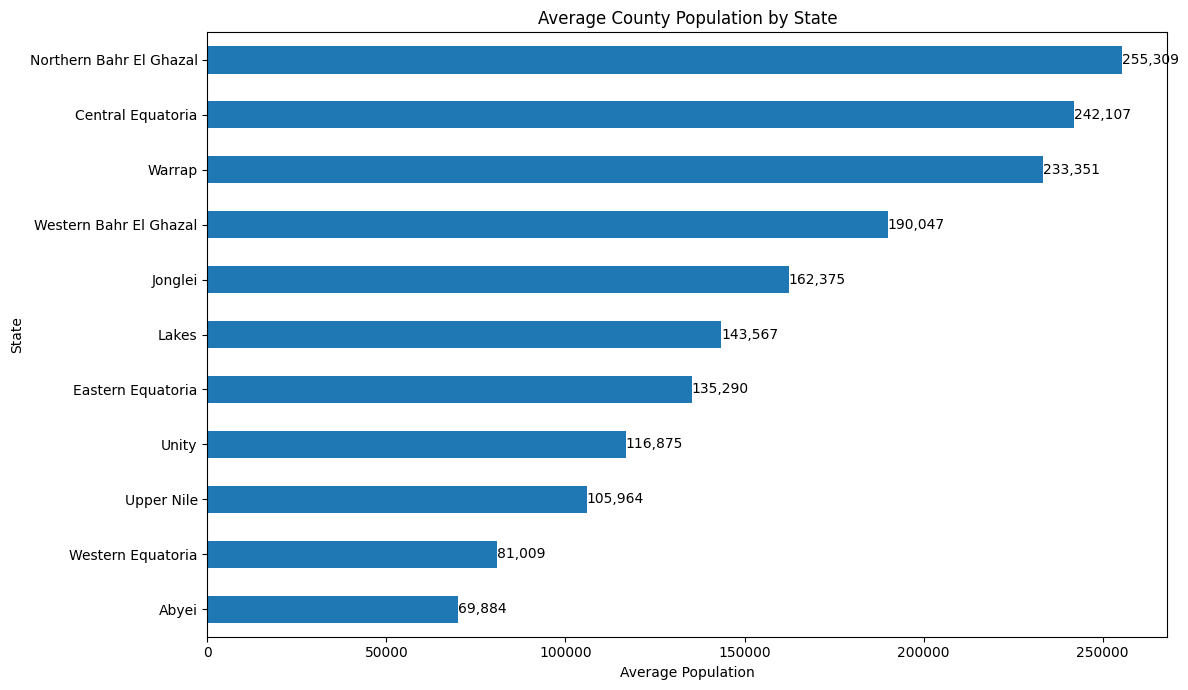

In [ ]:
plt.figure(figsize=(12, 7))

ax = population_by_state.sort_values().plot(
    kind="barh"
)

# Add data labels
for index, value in enumerate(population_by_state.sort_values()):
    plt.text(value, index, f'{value:,.0f}', va='center') # Format with commas and no decimal places

plt.title("Average County Population by State")
plt.xlabel("Average Population")
plt.ylabel("State")

plt.tight_layout()
plt.show()

**Average cereal production by state**

In [ ]:
production_by_state = (
    df.groupby("state")
    ["prior_year_cereal_production_tonnes"]
    .mean()
    .sort_values(ascending=False)
)

production_by_state

,prior_year_cereal_production_tonnes
state,
Western Bahr El Ghazal,40986.107895
Northern Bahr El Ghazal,24036.082632
Warrap,21876.346053
Central Equatoria,17725.894082
Lakes,15475.528618
Western Equatoria,14062.541053
Eastern Equatoria,13721.375329
Abyei,12642.311150
Jonglei,2576.188846


Visualization:

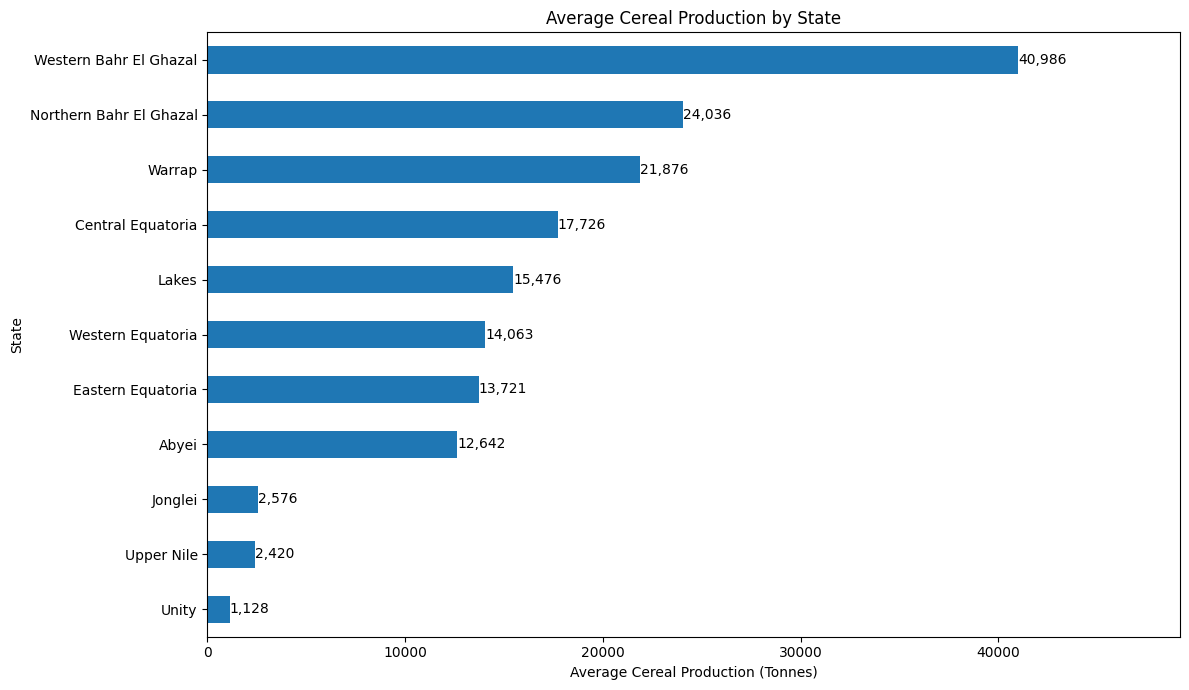

In [ ]:
plt.figure(figsize=(12, 7))

ax = production_by_state.sort_values().plot(
    kind="barh"
)

for index, value in enumerate(production_by_state.sort_values()):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.title("Average Cereal Production by State")
plt.xlabel("Average Cereal Production (Tonnes)")
plt.ylabel("State")

# Adjust x-axis limit to accommodate labels
plt.xlim(0, production_by_state.max() * 1.2) # Add 20% buffer for labels

plt.tight_layout()
plt.show()

**Average cereal gap by state**

In [ ]:
gap_by_state = (
    df.groupby("state")
    ["prior_year_cereal_gap_tonnes"]
    .mean()
    .sort_values()
)

gap_by_state

,prior_year_cereal_gap_tonnes
state,
Jonglei,-16079.519129
Central Equatoria,-10458.312779
Northern Bahr El Ghazal,-8756.146842
Unity,-8745.425439
Upper Nile,-5609.642119
Abyei,-4404.321583
Eastern Equatoria,-3123.175987
Warrap,-2721.292982
Lakes,-1803.475329


Visualization:

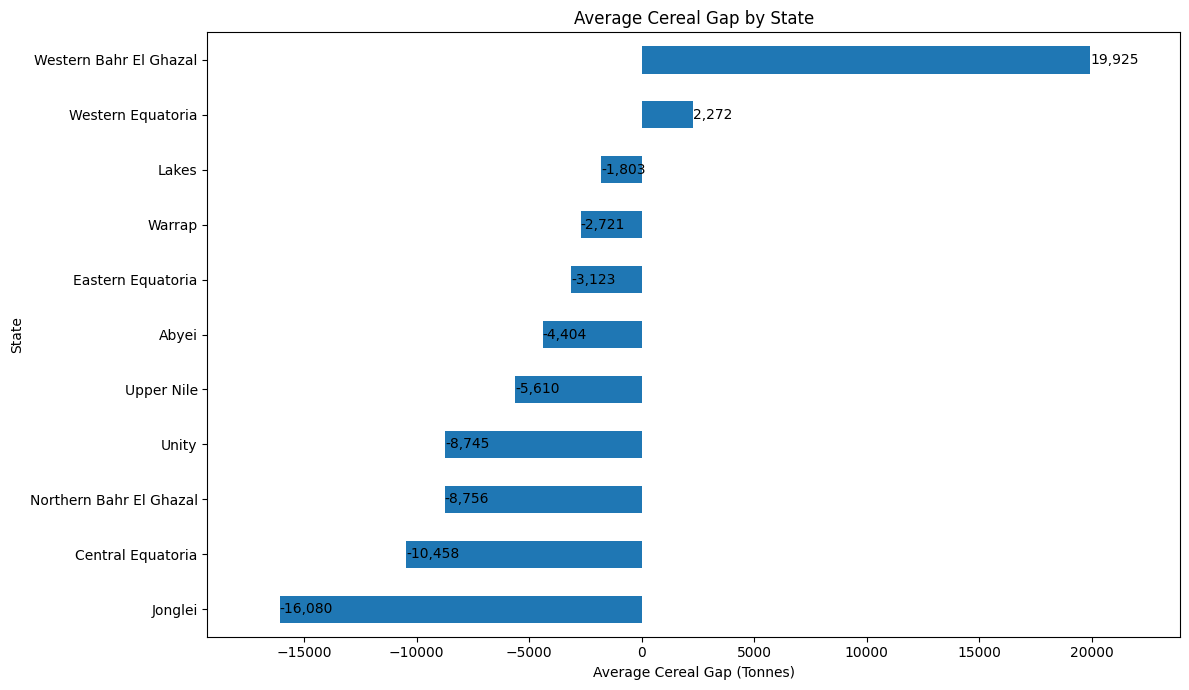

In [ ]:
plt.figure(figsize=(12, 7))

ax = gap_by_state.plot(
    kind="barh"
)

for index, value in enumerate(gap_by_state):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.title("Average Cereal Gap by State")
plt.xlabel("Average Cereal Gap (Tonnes)")
plt.ylabel("State")

# Adjust x-axis limit to accommodate labels
# Determine max absolute value for symmetric limits if needed, or simply extend max
abs_max_gap = max(abs(gap_by_state.min()), abs(gap_by_state.max()))
plt.xlim(gap_by_state.min() * 1.2, gap_by_state.max() * 1.2) # Add 20% buffer for labels on both sides

plt.tight_layout()
plt.show()

**Risk and previous Phase 3+ percentage by year**

In [ ]:
year_summary = df.groupby("start_year").agg(
    risk_rate=("food_insecurity_risk", "mean"),
    phase3plus_avg=("prior_period_phase3plus_pct", "mean"),
    population_avg=("population", "mean"),
    cereal_production_avg=(
        "prior_year_cereal_production_tonnes",
        "mean"
    ),
    cereal_gap_avg=(
        "prior_year_cereal_gap_tonnes",
        "mean"
    )
)

year_summary["risk_rate"] *= 100

year_summary

,risk_rate,phase3plus_avg,population_avg,cereal_production_avg,cereal_gap_avg
start_year,,,,,
2014,21.794872,19.407692,149830.064103,12088.958275,-5048.251497
2015,53.608247,28.826804,152675.314433,12142.738597,-5005.004121
2016,56.410256,31.535128,155174.730769,11679.847508,-5298.252780
2017,77.801724,38.228664,149167.267241,10389.568763,-6596.870555
2018,86.842105,53.507632,142472.489474,9610.841900,-6352.350740
2019,85.152838,49.351092,149114.956332,9243.301105,-6844.807724
2020,87.500000,44.663782,150579.673077,10316.243389,-6314.995593
2022,95.806452,55.798710,159504.296774,18376.367540,1732.791532
2023,92.735043,53.432051,158390.961538,11910.154976,-6235.407224


**Visualize yearly risk**

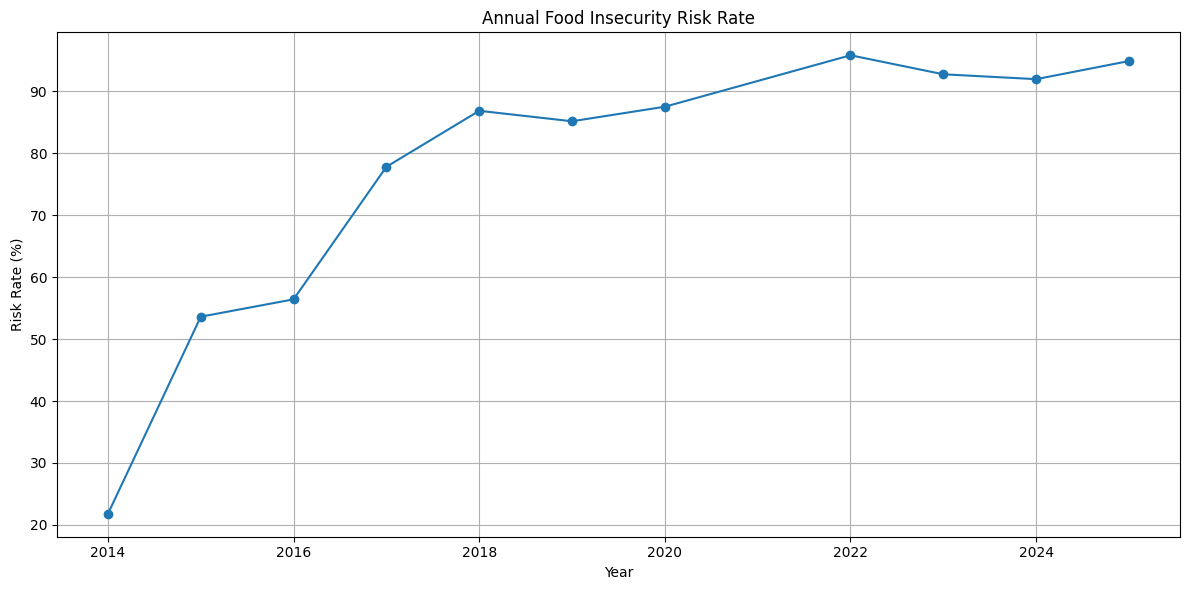

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    year_summary.index,
    year_summary["risk_rate"],
    marker="o"
)

plt.title("Annual Food Insecurity Risk Rate")
plt.xlabel("Year")
plt.ylabel("Risk Rate (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

**Analyze the relationship between previous IPC and target**

In [ ]:
phase3plus_categories = [
    "Crisis",
    "Emergency",
    "Catastrophe"
]

df["previous_phase3plus_binary"] = (
    df["prior_period_ipc_phase"]
    .isin(phase3plus_categories)
    .astype(int)
)

df[
    [
        "prior_period_ipc_phase",
        "previous_phase3plus_binary",
        "food_insecurity_risk"
    ]
].head()

,prior_period_ipc_phase,previous_phase3plus_binary,food_insecurity_risk
0,Minimal,0,0
1,Stressed,0,0
2,Minimal,0,0
3,Stressed,0,0
4,Stressed,0,0


Now analyze it:

In [ ]:
pd.crosstab(
    df["previous_phase3plus_binary"],
    df["food_insecurity_risk"],
    normalize="index"
) * 100

food_insecurity_risk,0,1
previous_phase3plus_binary,,
0,68.894952,31.105048
1,7.819104,92.180896


**Create a summary table**

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total observations",
        "Number of states",
        "Number of counties",
        "Number of features",
        "Risk = 1 observations",
        "Risk = 0 observations",
        "Risk = 1 percentage",
        "Risk = 0 percentage",
        "Minimum year",
        "Maximum year"
    ],

    "Value": [
        len(df),
        df["state"].nunique(),
        df["county"].nunique(),
        df.shape[1],
        (df["food_insecurity_risk"] == 1).sum(),
        (df["food_insecurity_risk"] == 0).sum(),
        (df["food_insecurity_risk"] == 1).mean() * 100,
        (df["food_insecurity_risk"] == 0).mean() * 100,
        df["start_year"].min(),
        df["start_year"].max()
    ]
})

summary

,Metric,Value
0,Total observations,3099.000000
1,Number of states,11.000000
2,Number of counties,79.000000
3,Number of features,13.000000
4,Risk = 1 observations,2409.000000
5,Risk = 0 observations,690.000000
6,Risk = 1 percentage,77.734753
7,Risk = 0 percentage,22.265247
8,Minimum year,2014.000000
9,Maximum year,2025.000000


**Export your cleaned analysis dataset**

In [ ]:
df.to_csv(
    "food_insecurity_analysis_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


**Export summary statistics**

In [ ]:
summary.to_csv(
    "food_insecurity_summary.csv",
    index=False
)

print("Summary saved successfully.")

Summary saved successfully.


**Final EDA dashboard**

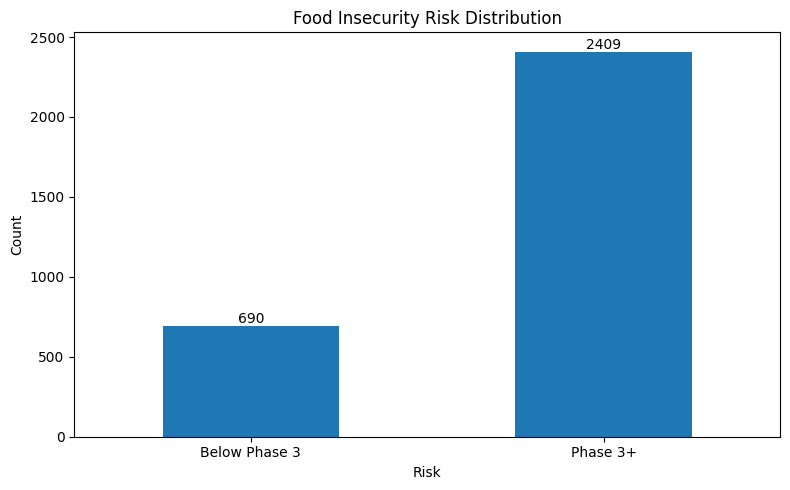

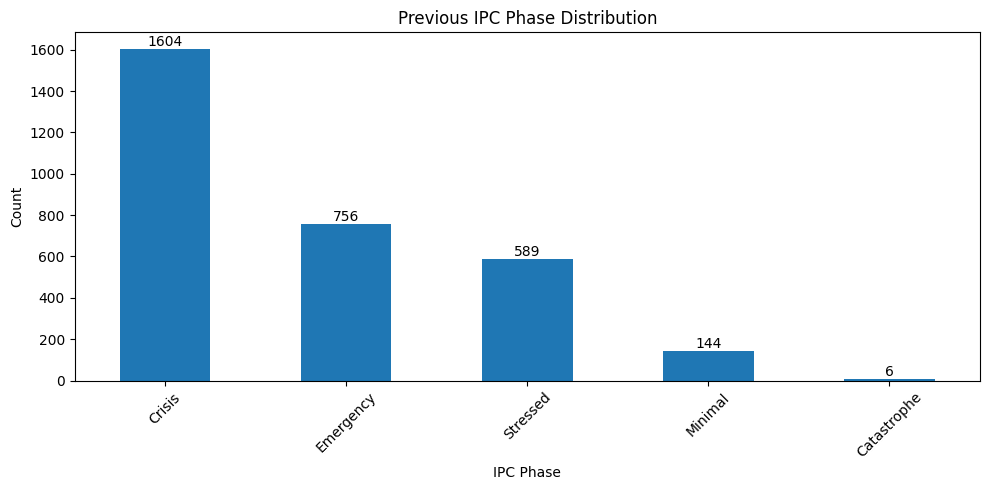

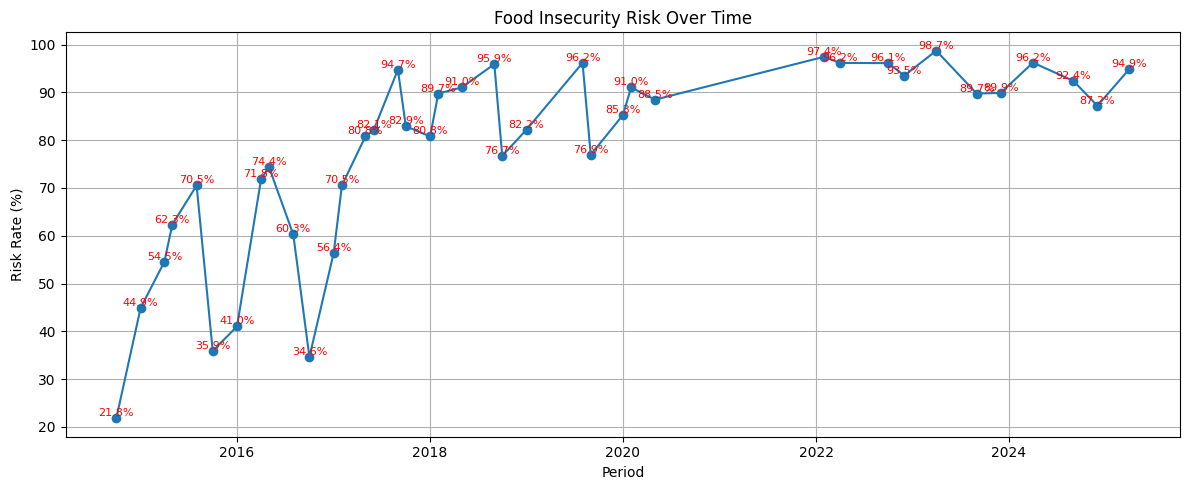

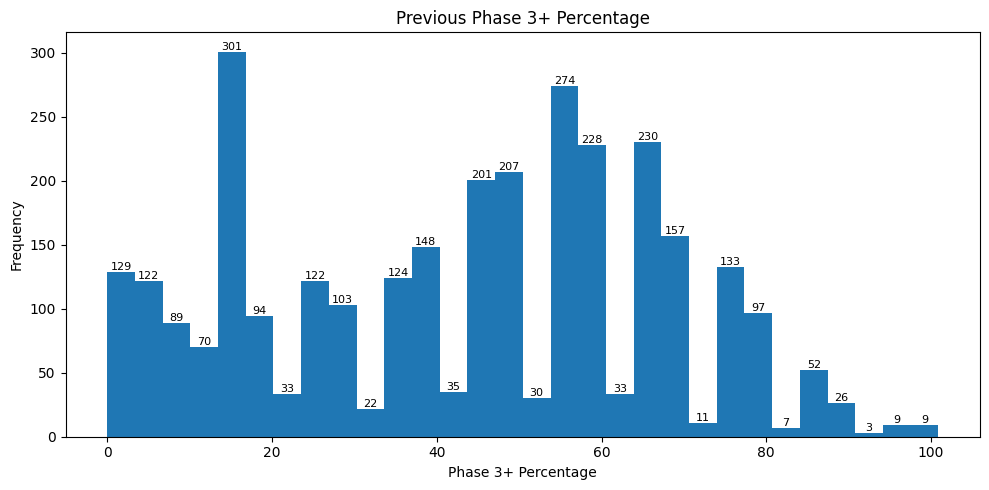

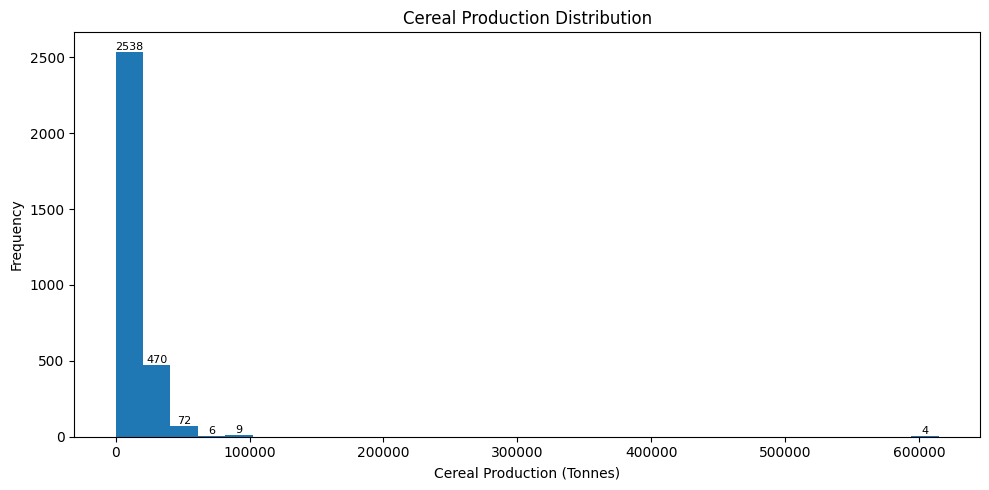

In [ ]:
# ============================================================
# FINAL KEY VISUALIZATIONS
# ============================================================

# 1. Target distribution
plt.figure(figsize=(8, 5))

ax1 = df["food_insecurity_risk"].value_counts().sort_index().plot(
    kind="bar"
)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f')

plt.title("Food Insecurity Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.xticks(
    [0, 1],
    ["Below Phase 3", "Phase 3+"],
    rotation=0
)

plt.tight_layout()
plt.show()


# 2. IPC distribution
plt.figure(figsize=(10, 5))

ax2 = df["prior_period_ipc_phase"].value_counts().plot(
    kind="bar"
)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.0f')

plt.title("Previous IPC Phase Distribution")
plt.xlabel("IPC Phase")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# 3. Risk over time
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_risk.index,
    monthly_risk,
    marker="o"
)

for x, y in zip(monthly_risk.index, monthly_risk):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='bottom', fontsize=8, color='red')

plt.title("Food Insecurity Risk Over Time")
plt.xlabel("Period")
plt.ylabel("Risk Rate (%)")
plt.grid(True)

plt.tight_layout()
plt.show()


# 4. Phase 3+ percentage
plt.figure(figsize=(10, 5))

counts, bins, patches = plt.hist(
    df["prior_period_phase3plus_pct"],
    bins=30
)

# Add data labels to the top of each bar
for count, bin in zip(counts, bins):
    if count > 0:
        plt.text(bin + (bins[1] - bins[0]) / 2, count, f'{int(count)}', ha='center', va='bottom', fontsize=8)

plt.title("Previous Phase 3+ Percentage")
plt.xlabel("Phase 3+ Percentage")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# 5. Cereal production
plt.figure(figsize=(10, 5))

counts, bins, patches = plt.hist(
    df["prior_year_cereal_production_tonnes"],
    bins=30
)

# Add data labels to the top of each bar
for count, bin in zip(counts, bins):
    if count > 0:
        plt.text(bin + (bins[1] - bins[0]) / 2, count, f'{int(count)}', ha='center', va='bottom', fontsize=8)

plt.title("Cereal Production Distribution")
plt.xlabel("Cereal Production (Tonnes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()